# PVGIS-only ST-GNN + SDE-Net (drift/diffusion) pipeline

Reproducible orchestrator for the final run on server **newzealand**.

Does **not** duplicate runner/analysis logic — it builds commands and reads the
CSVs they write, via `physiq_pv.experiments.sde_pipeline`.

Safety switches: `RUN_TRAINING`, `RUN_ANALYSIS`, `LOG_TO_WANDB`.

The selected experiment uses the paper regression likelihood: Gaussian NLL with beta=0. Run the notebook from the config cell onward; the results section reads only that run's output directory.

## 1. Setup

In [29]:
import os, sys, subprocess
from pathlib import Path
import pandas as pd

REPO_ROOT = Path.cwd()
if REPO_ROOT.name == 'notebooks':
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT))
os.environ['PYTHONPATH'] = str(REPO_ROOT) + os.pathsep + os.environ.get('PYTHONPATH', '')
os.chdir(REPO_ROOT)

from physiq_pv.experiments import sde_pipeline as pipe
print('repo root:', REPO_ROOT)

repo root: /home/apedalino/physiq_pv


In [30]:
PVGIS_DIR = pipe.PVGIS_DIR
EXPERIMENT = 'paper_faithful_gaussian'
TRAIN_NORMAL_ONLY = False  # True rimuove gli eventi rari da train/validation
ANOMALY_SOURCE = 'detector'  # 'climatology' | 'detector'
DETECTOR = 'mtgflow'  # 'mtgflow' | 'catch' | 'm2ad'
DETECTOR_SEED = 15
DETECTOR_ROOTS = {
    'mtgflow': Path('outputs/pvgis_mtgflow/downstream_dense') / f'seed_{DETECTOR_SEED}',
    'catch': Path('outputs/pvgis_catch_2005_2019'),
    'm2ad': Path('outputs/pvgis_m2ad_2005_2019'),
}
DETECTOR_ROOT = DETECTOR_ROOTS[DETECTOR]
if ANOMALY_SOURCE == 'detector':
    TEST_ANOMALY_SCORES = str(DETECTOR_ROOT / 'anomaly_scores.csv')
    TRAIN_ANOMALY_SCORES = str(DETECTOR_ROOT / 'train_anomaly_scores.csv')
else:
    TEST_ANOMALY_SCORES = pipe.TEST_ANOMALY_SCORES
    TRAIN_ANOMALY_SCORES = pipe.TRAIN_ANOMALY_SCORES
ANALYSIS_SCRIPT = pipe.ANALYSIS_SCRIPT

NEEDS_TRAIN_ANOMALIES = bool(TRAIN_NORMAL_ONLY) or ANOMALY_SOURCE == 'detector'
checks = {
    'PVGIS dir': Path(PVGIS_DIR).is_dir(),
    'test anomaly scores': Path(TEST_ANOMALY_SCORES).exists(),
    'train anomaly scores': (not NEEDS_TRAIN_ANOMALIES) or Path(TRAIN_ANOMALY_SCORES).exists(),
    'analysis script': Path(ANALYSIS_SCRIPT).exists(),
}
try:
    import physiq_pv.experiments.pvgis_stgnn_runner  # noqa: F401
    checks['runner importable'] = True
except Exception as e:
    checks['runner importable'] = False
    print('runner import error:', e)
for k, v in checks.items():
    print(('OK     ' if v else 'MISSING') + '  ' + k)

OK       PVGIS dir
OK       test anomaly scores
OK       train anomaly scores
OK       analysis script
OK       runner importable


If the anomaly scores are **missing**, regenerate them (run in a terminal — not launched automatically):

In [31]:
if not Path(TEST_ANOMALY_SCORES).exists() or (NEEDS_TRAIN_ANOMALIES and not Path(TRAIN_ANOMALY_SCORES).exists()):
    if ANOMALY_SOURCE == 'detector':
        detector_notebook = {'mtgflow': 'mtgflow_pvgis_workflow.ipynb', 'catch': 'pvgis_catch_pipeline.ipynb', 'm2ad': 'pvgis_m2ad_pipeline.ipynb'}[DETECTOR]
        print(f'Mancano i CSV {DETECTOR}: eseguire prima notebooks/{detector_notebook}')
    else:
        base = ('PYTHONPATH=$PWD python scripts/run_pvgis_climatology_anomaly_years.py'
            ' --pvgis-dir ' + PVGIS_DIR +
            ' --climatology-start-year 2005 --climatology-end-year 2018'
            ' --rolling-past-climatology'
            ' --quantile 0.975 --climatology-window-days 15 --min-climatology-years 3'
            ' --variables solar_irradiance_poa pv_power_output temperature_2m wind_speed_10m'
            ' --out-root outputs')
        print('# Test year 2019:')
        print(base + ' --years 2019')
        print()
        print('# Train years 2016-2018 (aggregated):')
        print(base + ' --years 2016,2017,2018 --aggregate-out-dir ' + str(Path(TRAIN_ANOMALY_SCORES).parent))
else:
    print('anomaly scores present.')

anomaly scores present.


## 2. Single-run config

In [32]:
# === EXPERIMENT SELECTOR ===
# One paper-faithful SDE-Net regression run, retaining the project's ST-GNN
# backbone, auxiliary irradiance objective, data and features.
BASE_CONFIG = {**pipe.DEFAULT_CONFIG,
    'name': f'paper_faithful_gaussian_{ANOMALY_SOURCE}_{DETECTOR}_ep60',
    'epochs': 60, 'batch_size': 16, 'lr': 1e-4, 'lr_g': 1e-2,
    'dropout': 0.0, 'train_normal_only': TRAIN_NORMAL_ONLY,
    'n_sde_steps': 4, 'sigma_max': 0.5,
    'sde_sigma_initial': 0.01, 'sde_sigma_warmup_epochs': 30,
    'ood_noise_std': 2.0, 'mc_samples': 10, 'seed': 1,
    'ood_smoke_test': True, 'ood_smoke_max_samples': 2048,
               'anomaly_source': ANOMALY_SOURCE,
               'detector_regional_quantile': 0.975,
}

out_dir = pipe.make_out_dir(BASE_CONFIG)
run_name = pipe.make_run_name(BASE_CONFIG)
print('experiment:', EXPERIMENT)
print('config    :', BASE_CONFIG)
print('out_dir   :', out_dir)
print('run_name  :', run_name)
if Path(out_dir).exists():
    print('NOTICE: out_dir already exists; the execution guard below will block reuse.')

experiment: paper_faithful_gaussian
config    : {'train_years': '2016,2017,2018', 'test_year': 2019, 'seq_len': 24, 'horizon': 1, 'target_variable': 'pv_power_output', 'model_type': 'stgnn', 'feature_set': 'full', 'epochs': 60, 'batch_size': 16, 'lr': 0.0001, 'lr_g': 0.01, 'dropout': 0.0, 'mc_samples': 10, 'seed': 1, 'n_sde_steps': 4, 'sigma_max': 0.5, 'sde_sigma_initial': 0.01, 'sde_sigma_warmup_epochs': 30, 'ood_noise_std': 2.0, 'ood_smoke_test': True, 'ood_smoke_max_samples': 2048, 'gradient_clip_norm': 100.0, 'lr_decay_epoch': 20, 'lr_decay_factor': 0.1, 'irradiance_loss_weight': 0.1, 'pv_target_clip_max': 'none', 'kt_poa_max': 1.6, 'distance_scale_km': 10.0, 'edge_prior_strength': 1.0, 'validation_metric': 'rmse_daytime', 'early_stopping_patience': 10, 'early_stopping_min_delta': 0.0, 'anomaly_source': 'detector', 'event_spatial_quantile': 0.99, 'event_tail_quantile': 0.975, 'detector_regional_quantile': 0.975, 'detector_min_temporal_coverage': 0.95, 'name': 'paper_faithful_gaussi

## 3. Training command

In [5]:
train_cmd = pipe.build_train_command(
    BASE_CONFIG, out_dir=out_dir, run_name=run_name,
    pvgis_dir=PVGIS_DIR, test_anomaly_scores=TEST_ANOMALY_SCORES,
    train_anomaly_scores=TRAIN_ANOMALY_SCORES, device='cuda', use_wandb=True)
# Keep W&B run logging enabled, but do not upload runner artifacts.
assert '--wandb' in train_cmd
assert '--no-wandb-upload-artifacts' in train_cmd
print(' \\\n  '.join(train_cmd))

/home/apedalino/physiq_pv/.venv/bin/python \
  -m \
  physiq_pv.experiments.pvgis_stgnn_runner \
  --pvgis-dir \
  /data/SentinelPV/pvgis_data/data/pvgis_summed_irradiance \
  --anomaly-scores \
  outputs/pvgis_mtgflow/downstream_dense/seed_15/anomaly_scores.csv \
  --train-years \
  2016,2017,2018 \
  --test-year \
  2019 \
  --seq-len \
  24 \
  --horizon \
  1 \
  --target-variable \
  pv_power_output \
  --model-type \
  stgnn \
  --feature-set \
  full \
  --irradiance-loss-weight \
  0.1 \
  --epochs \
  60 \
  --batch-size \
  16 \
  --lr \
  0.0001 \
  --lr-g \
  0.01 \
  --dropout \
  0.0 \
  --mc-samples \
  10 \
  --pv-target-clip-max \
  none \
  --seed \
  1 \
  --n-sde-steps \
  4 \
  --sigma-max \
  0.5 \
  --sde-sigma-initial \
  0.01 \
  --sde-sigma-warmup-epochs \
  30 \
  --ood-noise-std \
  2.0 \
  --ood-smoke-max-samples \
  2048 \
  --gradient-clip-norm \
  100.0 \
  --lr-decay-epoch \
  20 \
  --lr-decay-factor \
  0.1 \
  --kt-poa-max \
  1.6 \
  --distance-scal

## 4. Run training

Set `RUN_TRAINING = True` to actually launch.

In [6]:
RUN_TRAINING = True
EVAL_ONLY_PREDICTIONS = None  # path a predictions.csv esistente; richiede RUN_TRAINING=False
ALLOW_OVERWRITE = False

if RUN_TRAINING and EVAL_ONLY_PREDICTIONS:
    raise ValueError('Scegliere training oppure evaluation-only, non entrambi.')
if RUN_TRAINING:
    pipe.ensure_output_dir_available(out_dir, allow_overwrite=ALLOW_OVERWRITE)
    subprocess.run(train_cmd, check=True)
elif EVAL_ONLY_PREDICTIONS:
    eval_paths = pipe.relabel_detector_predictions_file(
        EVAL_ONLY_PREDICTIONS,
        TEST_ANOMALY_SCORES,
        TRAIN_ANOMALY_SCORES,
        out_dir,
        regional_quantile=BASE_CONFIG['detector_regional_quantile'],
        min_temporal_coverage=BASE_CONFIG['detector_min_temporal_coverage'],
        allow_overwrite=ALLOW_OVERWRITE,
    )
    print('Evaluation-only outputs:', eval_paths)
else:
    print('Training ed evaluation-only disattivati.')

INFO: paper-style protocol — two-source uncertainty (Kong et al. 2020): epistemic = Var of the SDE Brownian-path predictive means, aleatoric = mean of the Gaussian PV head variance. The primary interval (lower_pi/upper_pi) uses equal-tail quantiles of the Gaussian mixture across paths; the moment-matched Gaussian band is retained as a diagnostic. 


wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/apedalino/.netrc.
wandb: Currently logged in as: albertopedalino (albertopedalino-politecnico-di-torino) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: setting up run oyyzka3j
wandb: Tracking run with wandb version 0.26.1
wandb: Run data is saved locally in /home/apedalino/physiq_pv/wandb/run-20260728_201422-oyyzka3j
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run pvgis_stgnn_paper_faithful_gaussian_detector_mtgflow_ep60_seed1
wandb: ⭐️ View project at https://wandb.ai/albertopedalino-politecnico-di-torino/physiq_pv
wandb: 🚀 View run at https://wandb.ai/albertopedalino-politecnico-di-torino/physiq_pv/runs/oyyzka3j


[wandb] run id=oyyzka3j name=pvgis_stgnn_paper_faithful_gaussian_detector_mtgflow_ep60_seed1 -> out_dir=outputs/pvgis_stgnn_paper_faithful_gaussian_detector_mtgflow_ep60_seed1
[wandb] run metadata -> outputs/pvgis_stgnn_paper_faithful_gaussian_detector_mtgflow_ep60_seed1/wandb_run.json
[config] seed=1  batch_size=16  epochs=60  mc_samples=10  ood_smoke_test=True  skip_predictions_csv=False  train_years=2016,2017,2018  test_year=2019  pv_target_clip_max=None  n_sde_steps=4  sigma_max=0.5  sde_sigma_initial=0.01  sde_sigma_warmup_epochs=30  ood_noise_std=2.0  lr_g=0.01  gradient_clip_norm=100.0  lr_decay_epoch=20  lr_decay_factor=0.1  train_normal_only=False  anomaly_source=detector  event_spatial_quantile=0.99  event_tail_quantile=0.975  detector_regional_quantile=0.975  use_irradiance_head=True  use_irradiance_loss=True  irradiance_loss_weight=0.1  out_dir=outputs/pvgis_stgnn_paper_faithful_gaussian_detector_mtgflow_ep60_seed1
[1/6] Loading PVGIS years (train=[2016, 2017, 2018], test=2

wandb: uploading data; updating run metadata
wandb: uploading data
wandb: uploading data; uploading output.log; uploading wandb-summary.json
wandb: uploading data
wandb: uploading history steps 60-60, summary, console lines 93-645
wandb: 
wandb: Run history:
wandb:              clc_gaussian/daytime ▁
wandb: clc_gaussian/extreme_peak_daytime ▁
wandb:               clc_gaussian/global ▁
wandb:         clc_gaussian/high_daytime ▁
wandb:            clc_gaussian/nighttime ▁
wandb:               clc_gaussian/normal ▁
wandb:       clc_gaussian/normal_daytime ▁
wandb:     clc_gaussian/normal_nighttime ▁
wandb:         clc_gaussian/peak_daytime ▁
wandb:         clc_gaussian/rare_extreme ▁
wandb:                              +537 ...
wandb: 
wandb: Run summary:
wandb:                        best_epoch 59
wandb:            best_validation_metric rmse_daytime
wandb:             best_validation_score 71.16201
wandb:              clc_gaussian/daytime 0.49455
wandb: clc_gaussian/extreme_peak_daytime 

## 5. Post-hoc analysis

In [33]:
RUN_ANALYSIS = True

analysis_cmd = pipe.build_analysis_command(out_dir, BASE_CONFIG)
print(' \\\n  '.join(analysis_cmd))
if RUN_ANALYSIS:
    subprocess.run(analysis_cmd, check=True)
else:
    print('RUN_ANALYSIS is False — not launching.')

/home/apedalino/physiq_pv/.venv/bin/python \
  scripts/analyze_pvgis_daytime_report.py \
  --predictions \
  outputs/pvgis_stgnn_paper_faithful_gaussian_detector_mtgflow_ep60_seed1/predictions.csv \
  --out-dir \
  outputs/pvgis_stgnn_paper_faithful_gaussian_detector_mtgflow_ep60_seed1 \
  --epochs \
  60 \
  --dropout \
  0.0 \
  --mc-samples \
  10
[load] scanned 10,037,664 rows; 4,747,545 daytime candidates (solar > 10.0 W/m^2); kept 4,747,545 valid, skipped 0 invalid; 5,290,119 nighttime
[sharpness] target_range = 891.8600 (y_true_min 1.4100, y_true_max 893.2700)
[done] wrote:
  outputs/pvgis_stgnn_paper_faithful_gaussian_detector_mtgflow_ep60_seed1/daytime_bin_anomaly_report.md
  outputs/pvgis_stgnn_paper_faithful_gaussian_detector_mtgflow_ep60_seed1/daytime_anomaly_overview.csv
  outputs/pvgis_stgnn_paper_faithful_gaussian_detector_mtgflow_ep60_seed1/daytime_bin_summary.csv
  outputs/pvgis_stgnn_paper_faithful_gaussian_detector_mtgflow_ep60_seed1/daytime_bin_anomaly_metrics.csv
 

## 6. Results & figures

Reads the CSVs the runner/analysis wrote, then shows: summary tables, the
SDE band (predictive std) by anomaly group, and the post-hoc figures
(per-sample MAE/NMPIL boxplots + pooled PICP/CLC bar charts, one figure per
production-percentage bin, split by anomaly category). The ST-GNN SDE head
reports epistemic and aleatoric components separately.

In [34]:
def _read(name):
    p = Path(out_dir) / name
    return pd.read_csv(p) if p.exists() else None

RESULT_FILES = ['metrics_global.csv','metrics_daytime.csv','metrics_by_anomaly_label.csv',
                'residual_bias_and_bin_metrics.csv','daytime_bin_summary.csv',
                'daytime_bin_anomaly_metrics.csv','frequency_weighted_bin_summary.csv',
                'uncertainty_response.csv','sharpness_overview.csv']
results = {n: _read(n) for n in RESULT_FILES}
for n, df in results.items():
    print((('OK  ' if df is not None else '--  ') + n) + (('  ' + str(df.shape)) if df is not None else ''))

OK  metrics_global.csv  (1, 9)
OK  metrics_daytime.csv  (12, 26)
OK  metrics_by_anomaly_label.csv  (4, 9)
OK  residual_bias_and_bin_metrics.csv  (19, 24)
OK  daytime_bin_summary.csv  (5, 9)
OK  daytime_bin_anomaly_metrics.csv  (30, 25)
OK  frequency_weighted_bin_summary.csv  (6, 14)
OK  uncertainty_response.csv  (5, 10)
OK  sharpness_overview.csv  (7, 11)


In [35]:
sharp = results['sharpness_overview.csv']
if sharp is not None:
    cols = [c for c in ['scope','count','picp','mae','rmse','mean_std','mpiw','nmpil'] if c in sharp.columns]
    display(sharp[cols])
bins = results['daytime_bin_summary.csv']
if bins is not None:
    display(bins)
freq = results['frequency_weighted_bin_summary.csv']
if freq is not None:
    display(freq)
unc = results['uncertainty_response.csv']
if unc is not None:
    display(unc)

,scope,count,picp,mae,rmse,mean_std,mpiw,nmpil
0,overall_daytime,4747545,0.953794,42.822288,69.539028,57.310667,224.653805,0.251894
1,normal,4547069,0.953872,42.581346,69.187512,57.088166,223.781620,0.250916
2,rare_extreme,200476,0.952029,48.287190,77.082573,62.357302,244.436138,0.274075
3,unusually_low_solar_potential,0,NaN,NaN,NaN,NaN,NaN,NaN
4,unusually_high_solar_potential,0,NaN,NaN,NaN,NaN,NaN,NaN
5,extreme_temperature_condition,0,NaN,NaN,NaN,NaN,NaN,NaN
6,extreme_wind_condition,0,NaN,NaN,NaN,NaN,NaN,NaN


,bin,count,mae,rmse,picp,mean_std,mpiw,nmpil,production_peak_nmpil
0,daytime_0_20_pct,1934608,40.000369,67.943361,0.940692,42.939240,168.318821,0.188728,0.236089
1,daytime_20_40_pct,856630,46.372110,69.246531,0.947207,65.231383,255.702431,0.286707,0.358656
2,daytime_40_60_pct,736468,46.622363,69.807226,0.960357,71.389051,279.840106,0.313771,0.392513
3,daytime_60_80_pct,669745,45.138903,74.857512,0.967540,69.717719,273.288625,0.306425,0.383323
4,daytime_80_100_pct,550094,39.310611,68.449700,0.984610,61.564694,241.329233,0.270591,0.338496


,category,count,frequency_of_daytime,frequency_weighted_picp,frequency_weighted_mae,frequency_weighted_rmse,frequency_weighted_abs_picp_gap,frequency_weighted_undercoverage_gap,frequency_weighted_overcoverage_gap,dominant_bin,dominant_bin_frequency,max_gap_bin,max_gap_bin_frequency,max_abs_picp_gap
0,normal,4547069,0.957773,0.953872,42.581346,69.187512,0.012029,0.004078,0.007951,daytime_0_20_pct,0.407523,daytime_80_100_pct,0.112954,0.034434
1,rare_extreme,200476,0.042227,0.952029,48.287190,77.082573,0.020908,0.009440,0.011469,daytime_0_20_pct,0.406892,daytime_80_100_pct,0.181982,0.037090
2,unusually_low_solar_potential,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,unusually_high_solar_potential,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,extreme_temperature_condition,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,extreme_wind_condition,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,category,mae_ratio_vs_normal,rmse_ratio_vs_normal,std_ratio_vs_normal,picp_delta_vs_normal,mpiw_ratio_vs_normal,nmpil_ratio_vs_normal,underdispersion_flag,epistemic_std_ratio_vs_normal,aleatoric_std_ratio_vs_normal
0,rare_extreme,1.133999,1.114111,1.092298,-0.001843,1.092298,1.092298,True,0.78016,1.092301
1,unusually_low_solar_potential,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN
2,unusually_high_solar_potential,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN
3,extreme_temperature_condition,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN
4,extreme_wind_condition,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN


In [36]:
# SDE total predictive std by anomaly group. Seasonal anomaly labels are
# evaluation strata only.
_pred = Path(out_dir) / 'predictions.csv'
if _pred.exists():
    _df = pd.read_csv(_pred, usecols=['anomaly_group', 'solar_irradiance_poa_target',
                                      'y_pred_std'])
    _day = _df[_df['solar_irradiance_poa_target'] > 10.0]
    display(_day.groupby('anomaly_group')[['y_pred_std']].mean())
else:
    print('predictions.csv not found — run training first.')

,y_pred_std
anomaly_group,
normal,56.989964
rare_or_extreme,61.850696


In [37]:
import pandas as pd
# Epistemic vs aleatoric on the CURRENTLY SELECTED experiment (run cell 2 first).
# Does NOT reassign out_dir and uses a private _ea frame so it can't shadow the
# reliability cell's `df` guard.
_ea = pd.read_csv(str(Path(out_dir) / 'predictions.csv'),
                  usecols=['epistemic_std', 'aleatoric_std', 'solar_irradiance_poa_target'])
_ea_day = _ea[_ea['solar_irradiance_poa_target'] > 10]
print('out_dir:', out_dir)
print(_ea_day[['epistemic_std', 'aleatoric_std']].mean())
print('epistemic / aleatoric ratio:',
      (_ea_day['epistemic_std'].mean() / _ea_day['aleatoric_std'].mean()).round(4))

out_dir: outputs/pvgis_stgnn_paper_faithful_gaussian_detector_mtgflow_ep60_seed1
epistemic_std     0.025012
aleatoric_std    57.310481
dtype: float64
epistemic / aleatoric ratio: 0.0004


reading: outputs/pvgis_stgnn_paper_faithful_gaussian_detector_mtgflow_ep60_seed1/predictions.csv
dist=gaussian  target_range=891.86  RMSE=69.54  gaussian_z=1.960  (gamma=0.95, eta=9.0)
                             model   PICP   MPIW  NMPIL  MPIW_RMSE    CLC
                  model (saved PI) 0.9538 224.65 0.2519      3.231 0.4953
model (Gaussian moment diagnostic) 0.9538 224.65 0.2519      3.231 0.4953

Controlled pseudo-OOD smoke test (not real held-out OOD):
             score  n_id  n_ood  id_mean    ood_mean  ood_to_id_ratio  auroc  aupr_out  aupr_in  tnr_at_tpr95  detection_accuracy
epistemic_variance  2048   2048 0.010141 2676.791911    263963.430790    1.0       1.0      1.0           1.0                 1.0
         diffusion  2048   2048 0.000298    0.999774      3356.598095    1.0       1.0      1.0           1.0                 1.0


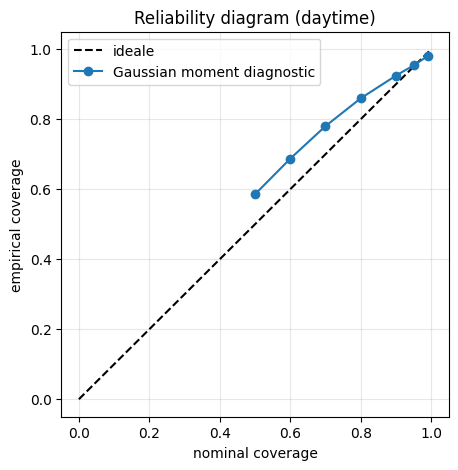

 nominal  empirical
    0.50     0.5856
    0.60     0.6873
    0.70     0.7803
    0.80     0.8597
    0.90     0.9245
    0.95     0.9538
    0.99     0.9803


In [38]:
import numpy as np, pandas as pd
from scipy.stats import norm
import matplotlib.pyplot as plt

# Predictions of the CURRENTLY SELECTED experiment — derive out_dir from
# BASE_CONFIG so a stale global out_dir can't point at the wrong run.
out_dir = pipe.make_out_dir(BASE_CONFIG)
PRED_CSV = str(Path(out_dir) / "predictions.csv")
print("reading:", PRED_CSV)
GAMMA, ETA = 0.95, 9.0
SOLAR_COL, SOLAR_THR = "solar_irradiance_poa_target", 10.0

# Primary intervals are exact quantiles of the sampled Gaussian mixture.
# A moment-matched Gaussian band is retained only as a diagnostic.
NLL_DIST = 'gaussian'
z = float(norm.ppf(0.5 + GAMMA / 2))

want = ["y_true", "y_pred_mean", "y_pred_std_raw", "lower_pi", "upper_pi",
        SOLAR_COL, "timestamp", "location"]
# Always load from the selected run's CSV (no stale in-memory df shortcut).
d = pd.read_csv(PRED_CSV, usecols=lambda c: c in want)

# --- daytime + finite ---
d = d[d[SOLAR_COL] > SOLAR_THR]
need = ["y_true", "y_pred_mean", "y_pred_std_raw"]
d = d[np.isfinite(d[need].to_numpy()).all(axis=1)].reset_index(drop=True)

y = d["y_true"].to_numpy(float)
mu = d["y_pred_mean"].to_numpy(float)
sig = d["y_pred_std_raw"].to_numpy(float)

rng = y.max() - y.min()                       # target_range (come report)
rmse = np.sqrt(np.mean((mu - y) ** 2))

clc = lambda picp, nmpil: nmpil * (1.0 + np.exp(-ETA * (picp - GAMMA)))  # = report CLC

def metrics(lo, hi, name):
    inside = (y >= lo) & (y <= hi)
    picp, mpiw = inside.mean(), np.mean(hi - lo)
    nmpil = mpiw / rng
    return dict(model=name, PICP=round(picp, 4), MPIW=round(mpiw, 2),
                NMPIL=round(nmpil, 4), MPIW_RMSE=round(mpiw / rmse, 3),
                CLC=round(clc(picp, nmpil), 4))

rows = []
# 1) modello, PI Gaussian-mixture primari salvati dal runner
rows.append(metrics(d["lower_pi"].to_numpy(float), d["upper_pi"].to_numpy(float), "model (saved PI)"))
# 2) diagnostica moment-matched Gaussian sulla varianza totale
rows.append(metrics(mu - z * sig, mu + z * sig, "model (Gaussian moment diagnostic)"))
# No test-fitted homoscedastic/climatology baselines: fitting them on y_test
# would leak evaluation targets and they are not part of this primary run.

res = pd.DataFrame(rows)[["model", "PICP", "MPIW", "NMPIL", "MPIW_RMSE", "CLC"]]
print(f"dist={NLL_DIST}" +
      f"  target_range={rng:.2f}  RMSE={rmse:.2f}  gaussian_z={z:.3f}  (gamma={GAMMA}, eta={ETA})")
print(res.to_string(index=False))
ood_smoke_path = Path(out_dir) / 'ood_smoke_metrics.csv'
if ood_smoke_path.exists():
    print('\nControlled pseudo-OOD smoke test (not real held-out OOD):')
    print(pd.read_csv(ood_smoke_path).to_string(index=False))

# --- reliability diagram della sola diagnostica Gaussian moment-matched ---
levels = np.array([0.5, 0.6, 0.7, 0.8, 0.9, 0.95, 0.99])
emp = np.array([((y >= mu - norm.ppf(.5 + L / 2) * sig) & (y <= mu + norm.ppf(.5 + L / 2) * sig)).mean() for L in levels])
plt.figure(figsize=(5, 5))
plt.plot([0, 1], [0, 1], "k--", label="ideale")
plt.plot(levels, emp, "o-", label="Gaussian moment diagnostic")
plt.xlabel("nominal coverage"); plt.ylabel("empirical coverage")
plt.title("Reliability diagram (daytime)"); plt.legend(); plt.grid(alpha=.3); plt.show()
print(pd.DataFrame({"nominal": levels, "empirical": np.round(emp, 4)}).to_string(index=False))

In [39]:
# I grafici usano le statistiche esatte calcolate su tutte le righe dal report.
figure_paths = pipe.build_posthoc_figures(out_dir)
print('figures:', list(figure_paths))

figures: ['mae_daytime_0_20_pct_boxplot', 'mae_daytime_20_40_pct_boxplot', 'mae_daytime_40_60_pct_boxplot', 'mae_daytime_60_80_pct_boxplot', 'mae_daytime_80_100_pct_boxplot', 'nmpil_daytime_0_20_pct_boxplot', 'nmpil_daytime_20_40_pct_boxplot', 'nmpil_daytime_40_60_pct_boxplot', 'nmpil_daytime_60_80_pct_boxplot', 'nmpil_daytime_80_100_pct_boxplot', 'picp_daytime_0_20_pct_bar', 'picp_daytime_20_40_pct_bar', 'picp_daytime_40_60_pct_bar', 'picp_daytime_60_80_pct_bar', 'picp_daytime_80_100_pct_bar', 'clc_daytime_0_20_pct_bar', 'clc_daytime_20_40_pct_bar', 'clc_daytime_40_60_pct_bar', 'clc_daytime_60_80_pct_bar', 'clc_daytime_80_100_pct_bar', 'rmse_daytime_0_20_pct_bar', 'rmse_daytime_20_40_pct_bar', 'rmse_daytime_40_60_pct_bar', 'rmse_daytime_60_80_pct_bar', 'rmse_daytime_80_100_pct_bar', 'uncertainty_components_bar']


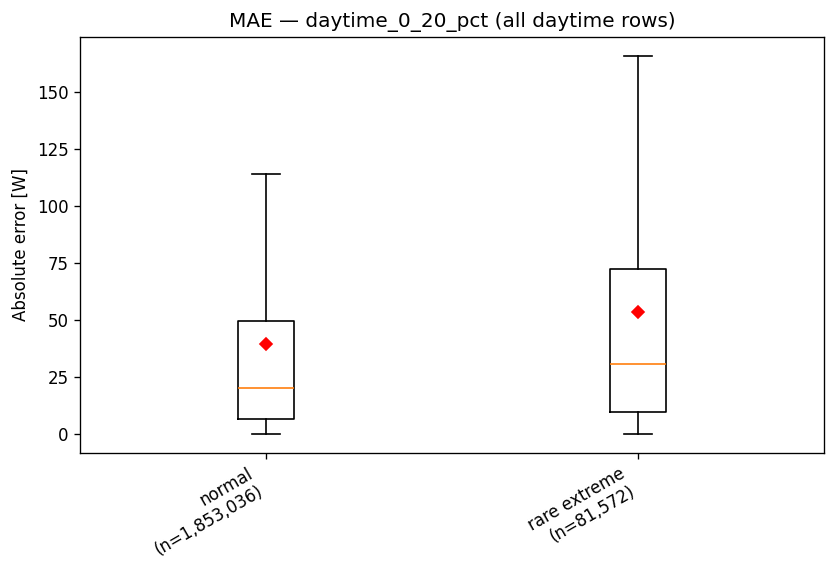

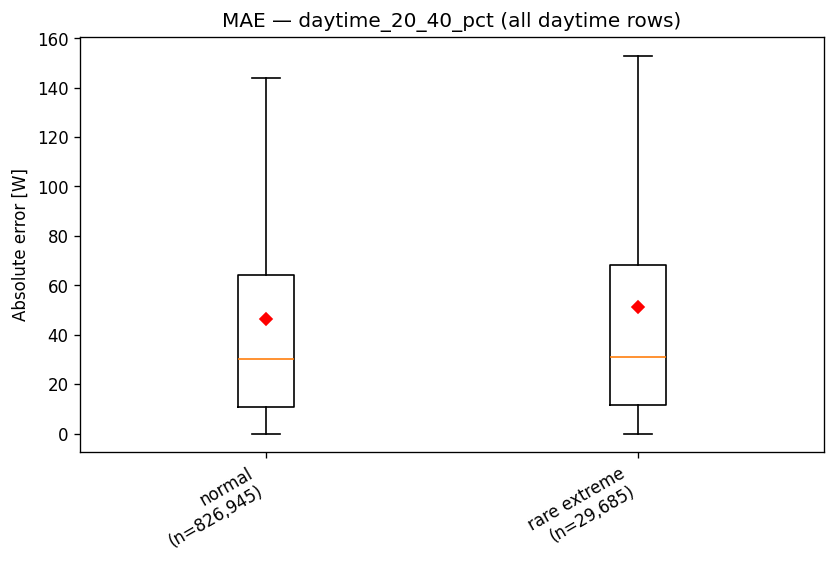

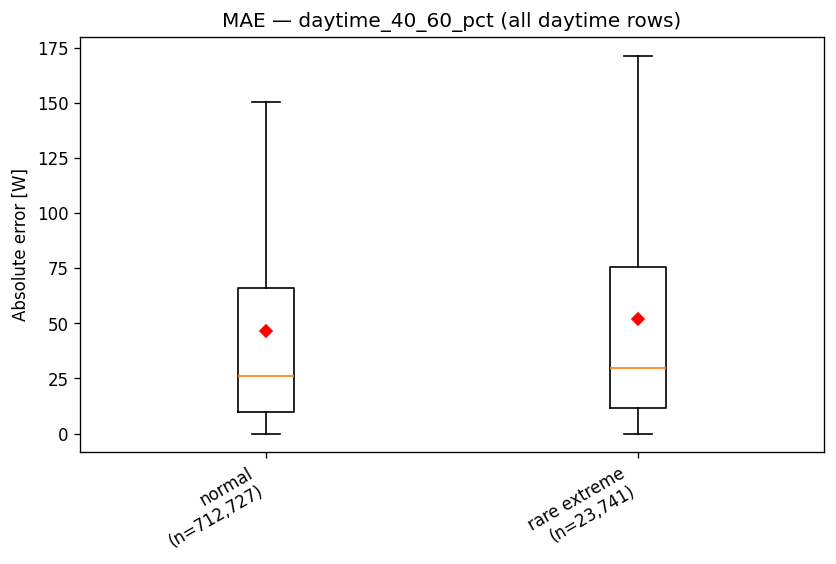

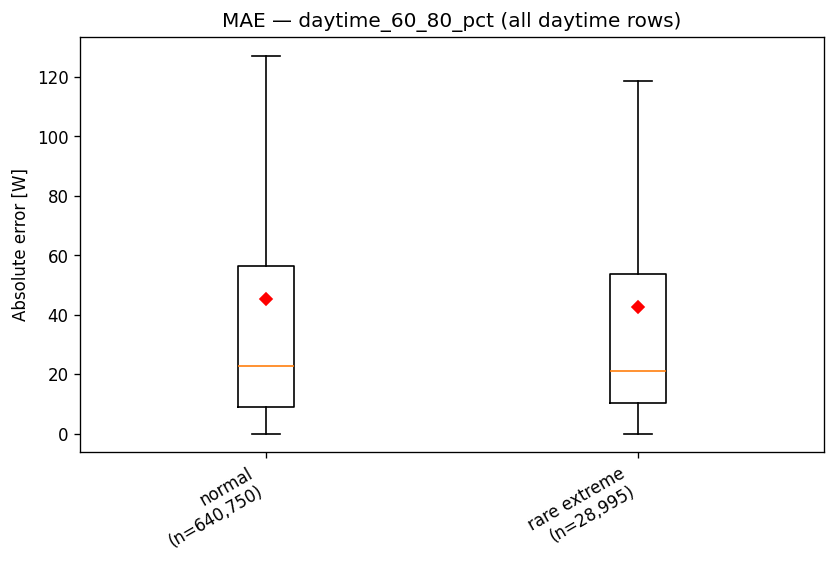

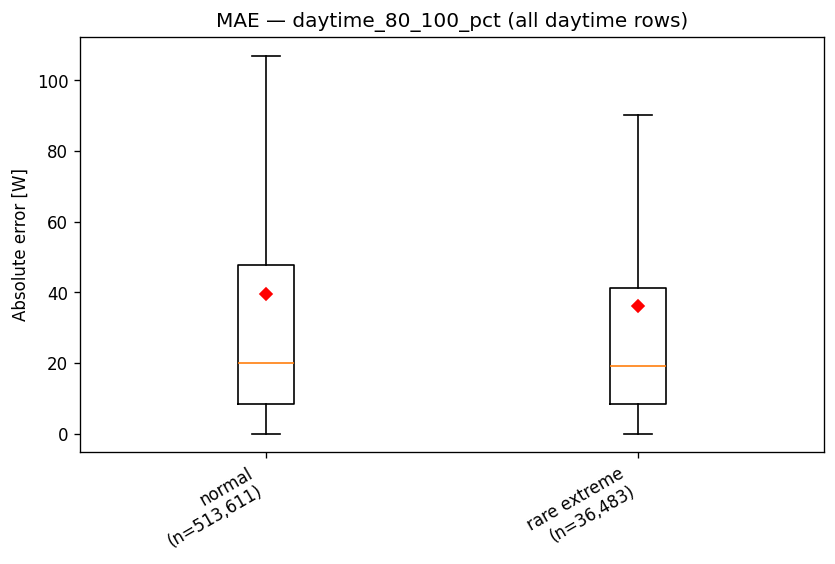

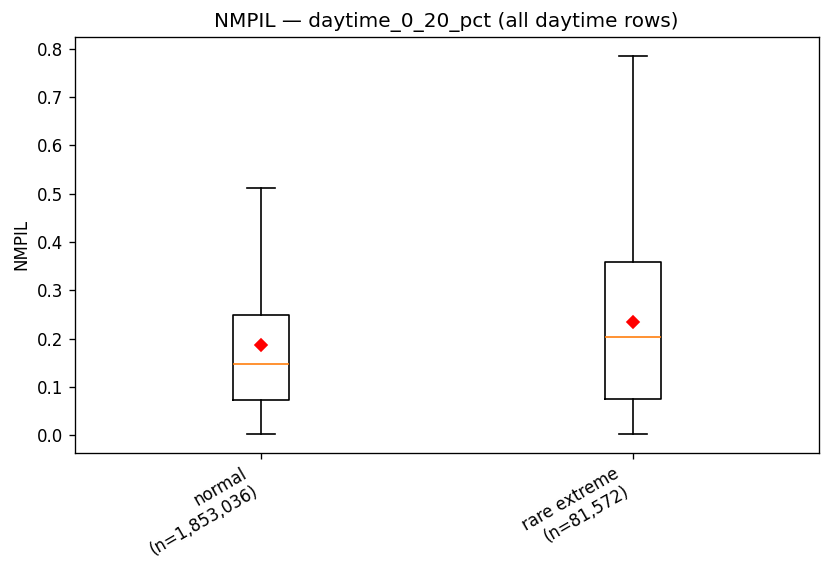

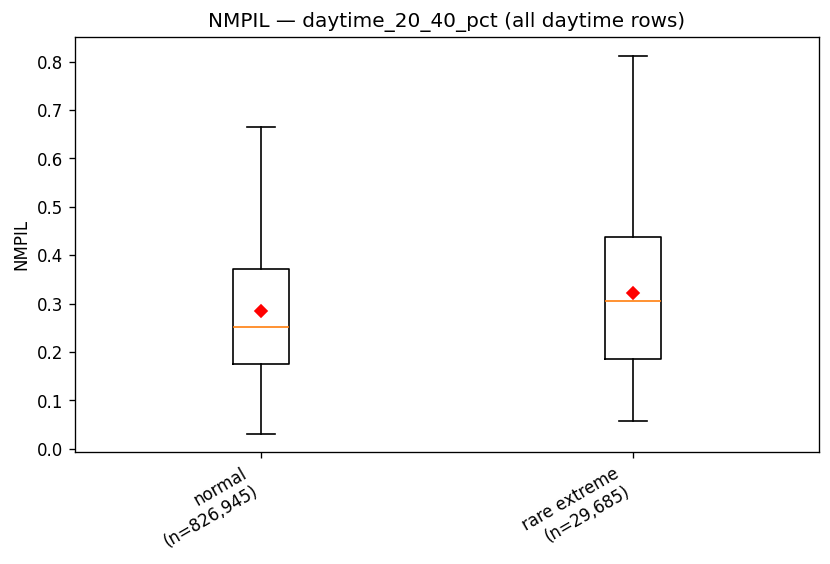

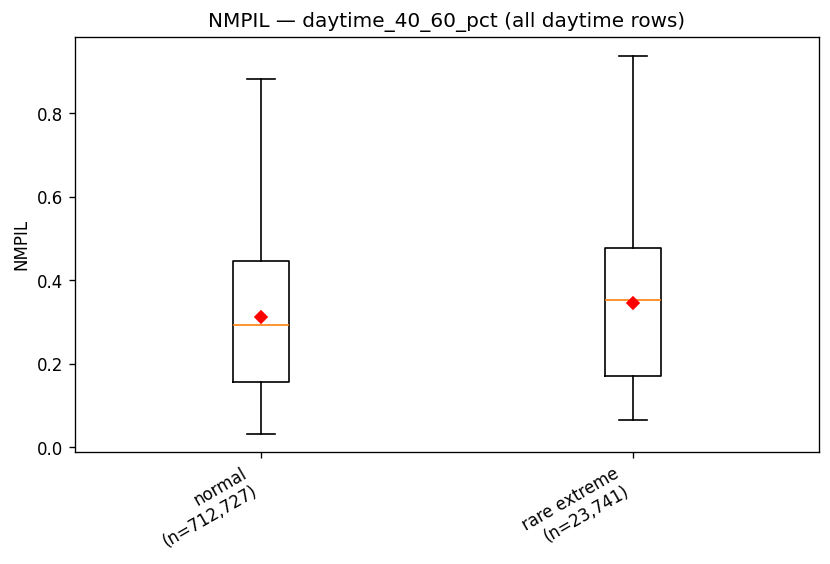

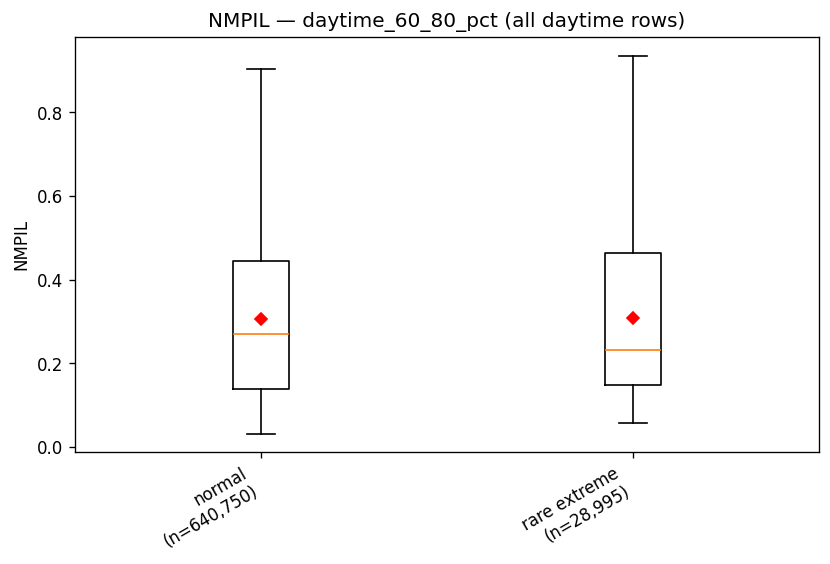

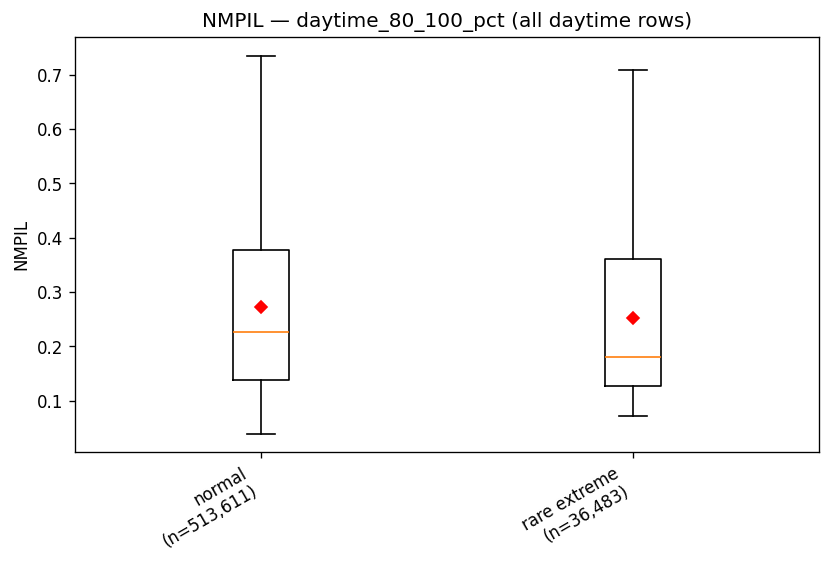

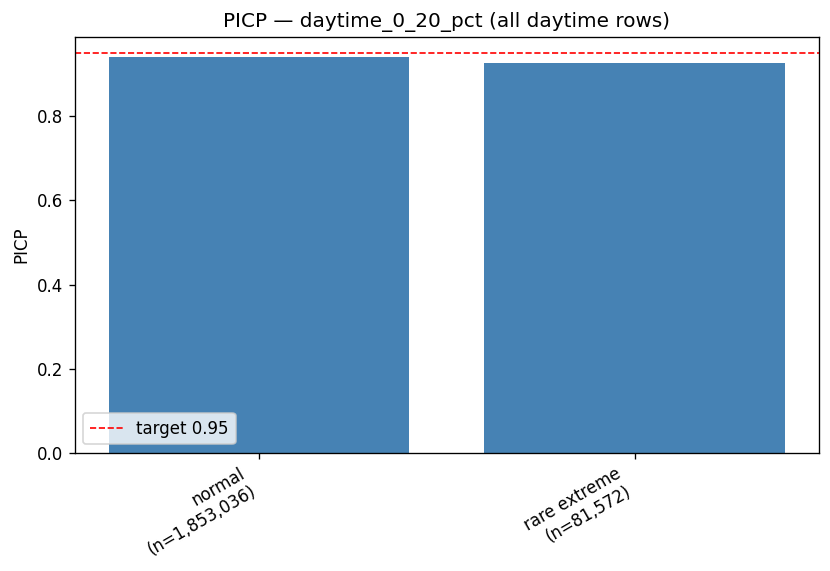

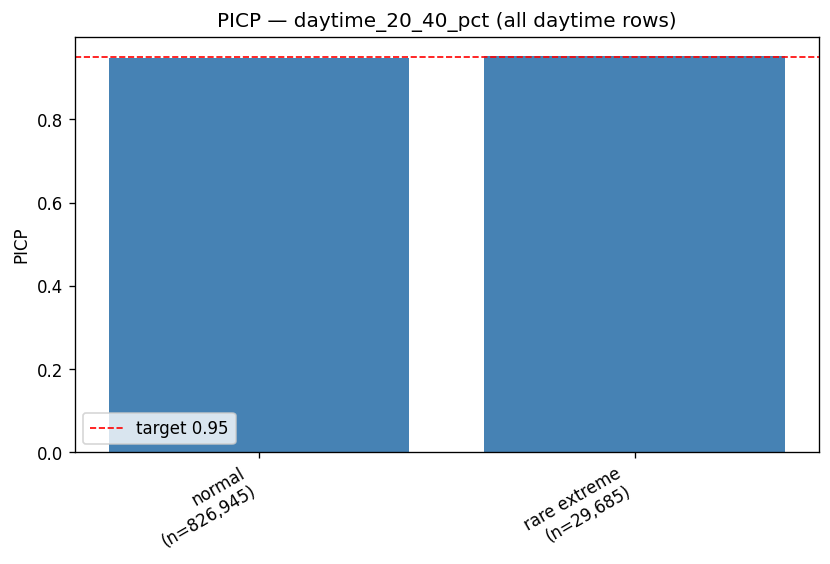

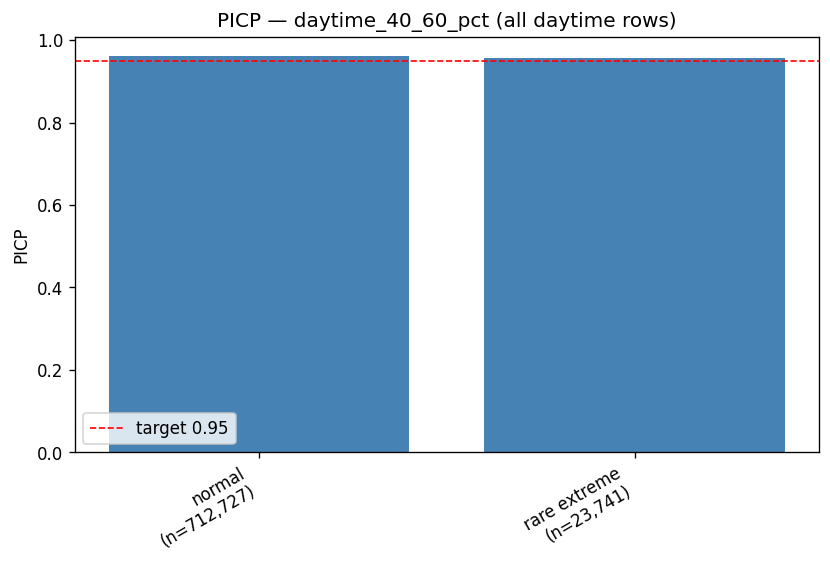

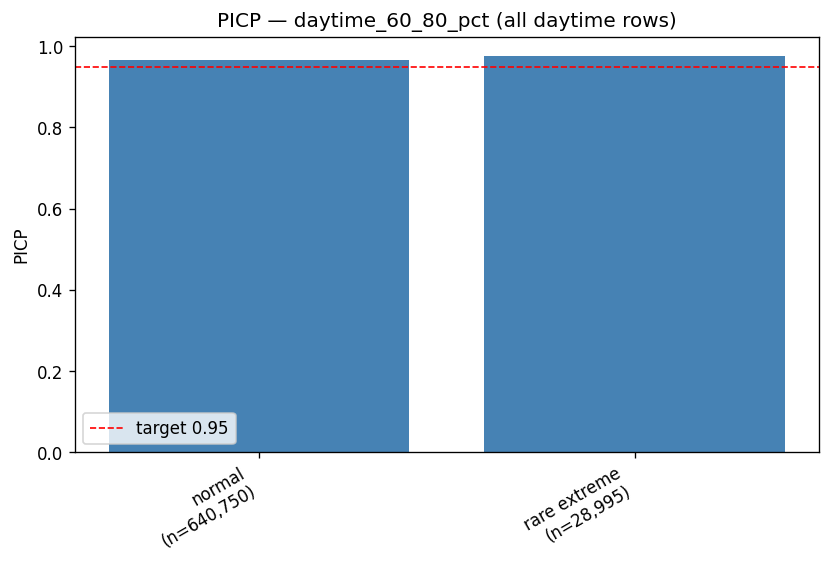

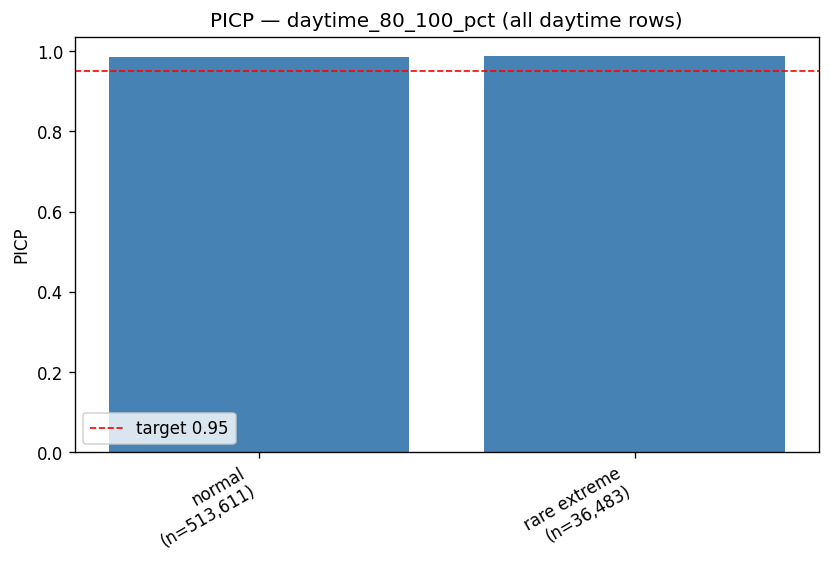

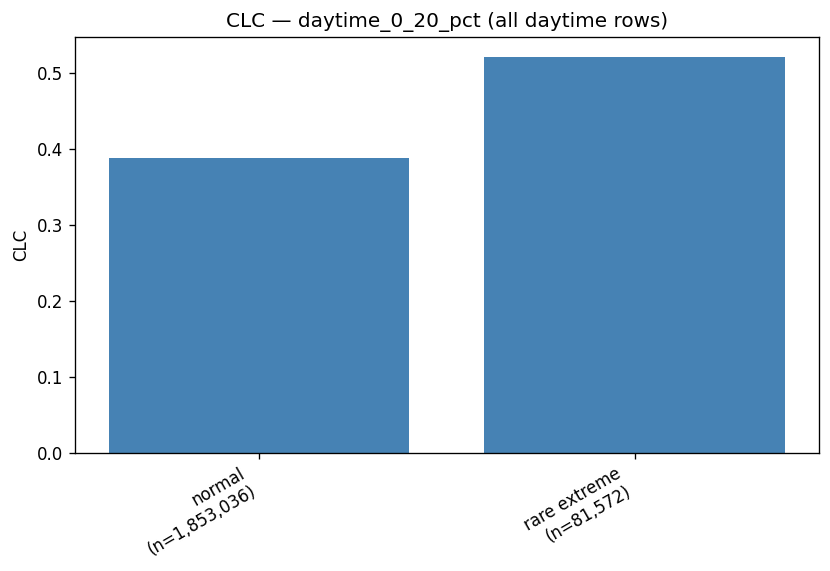

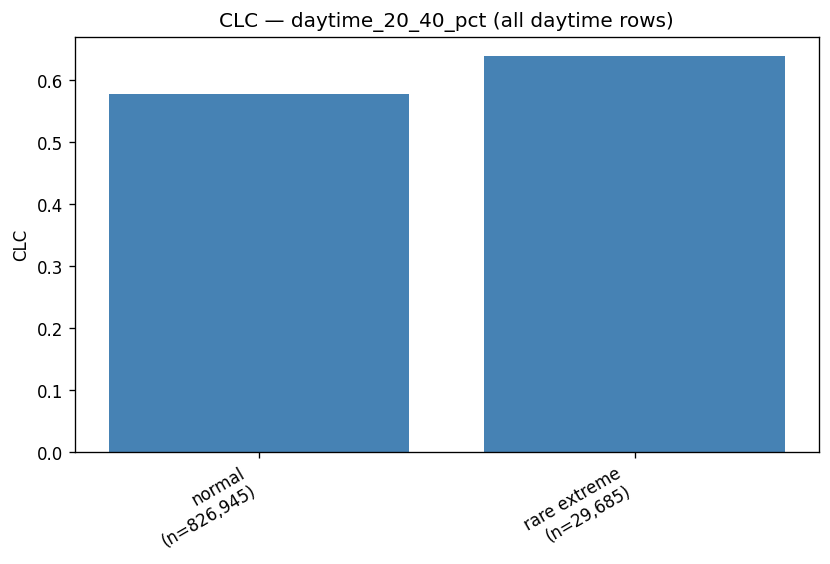

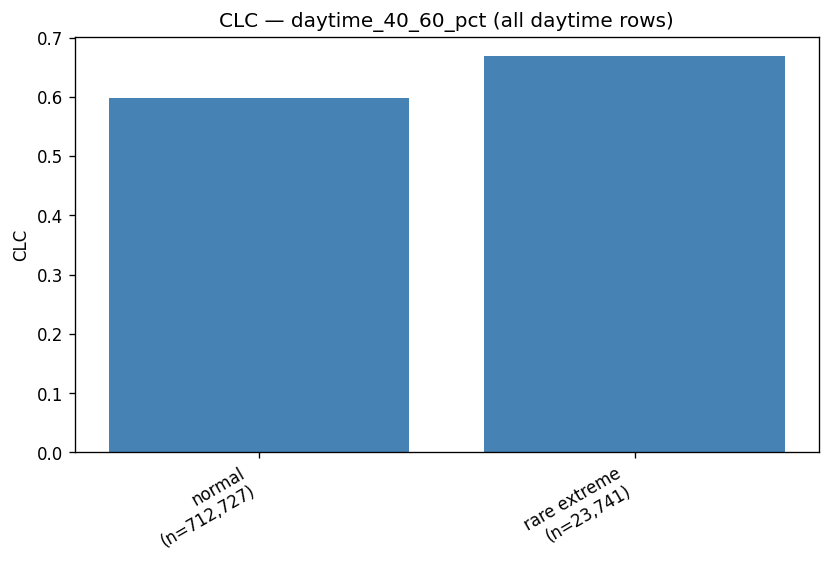

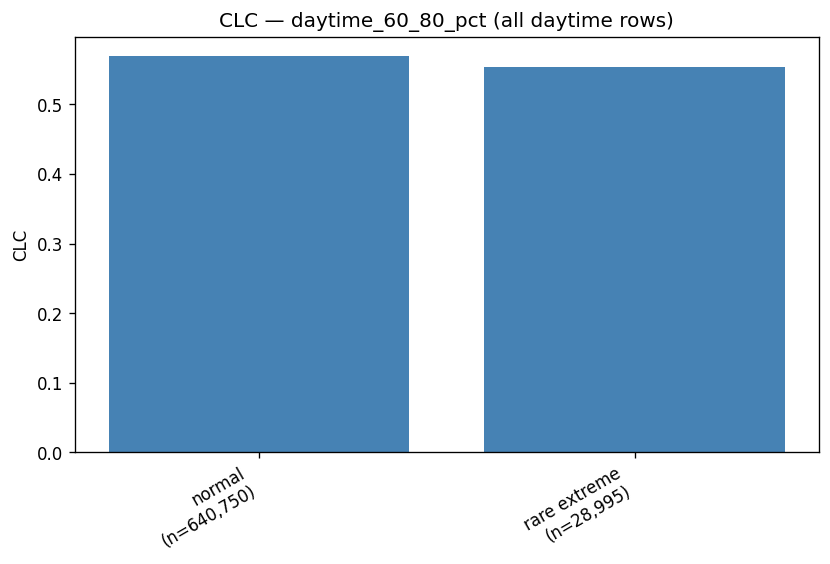

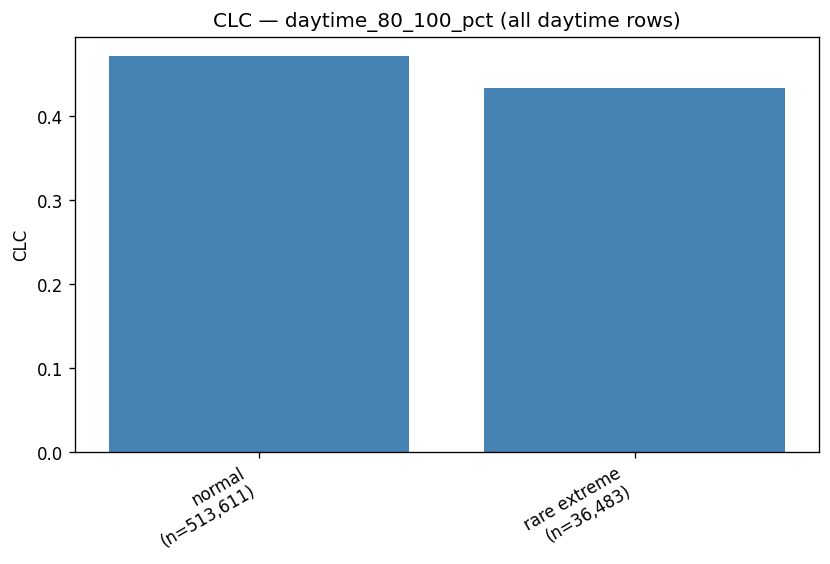

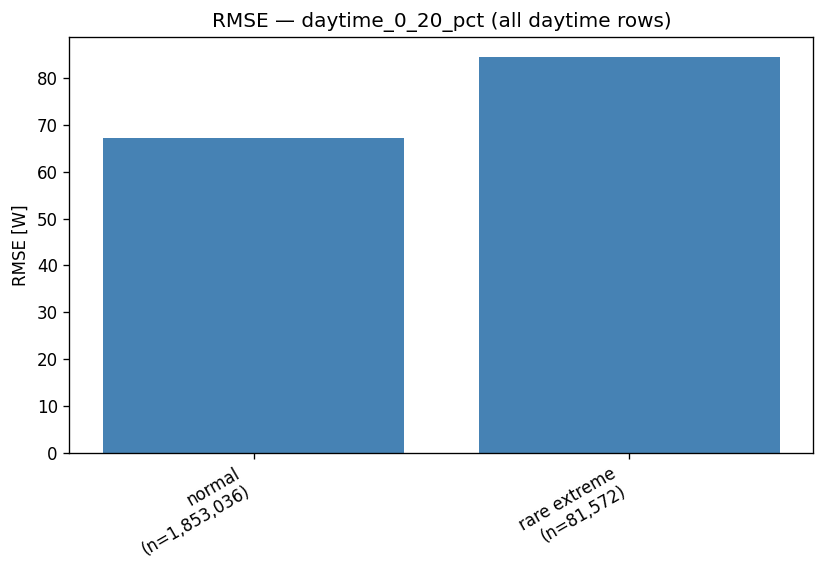

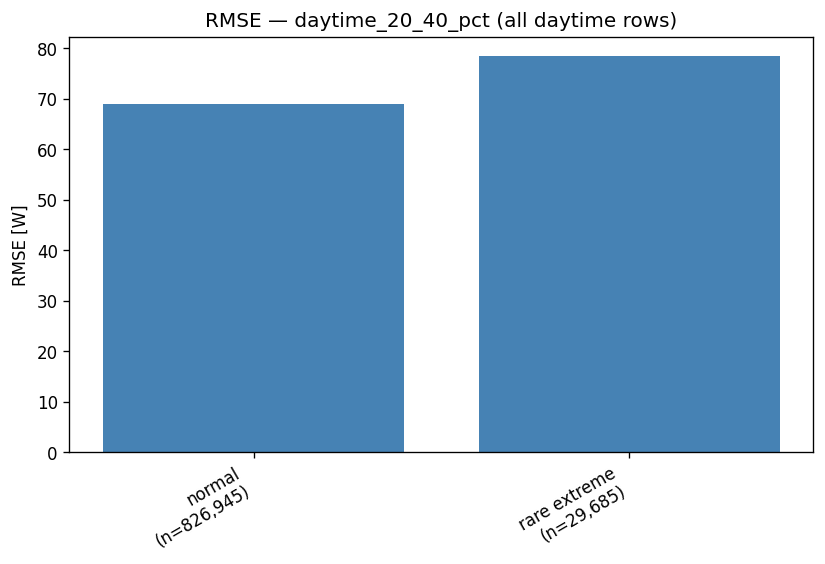

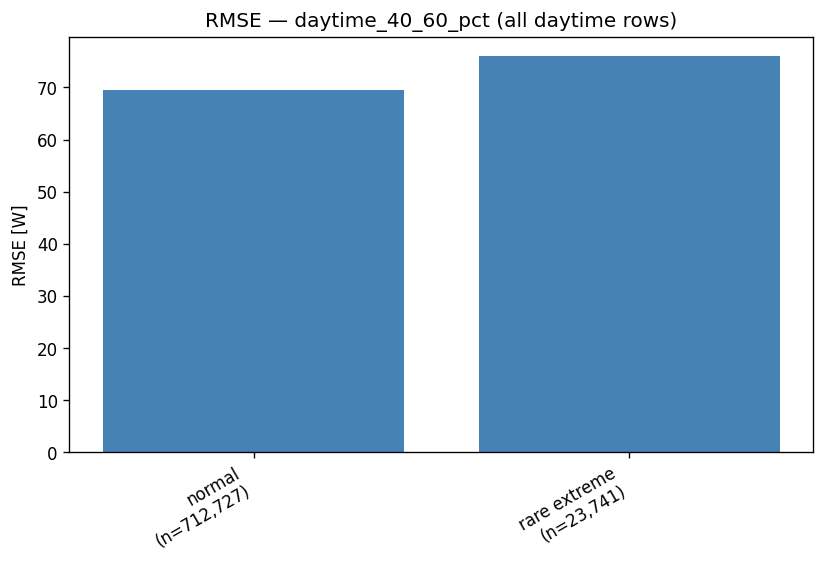

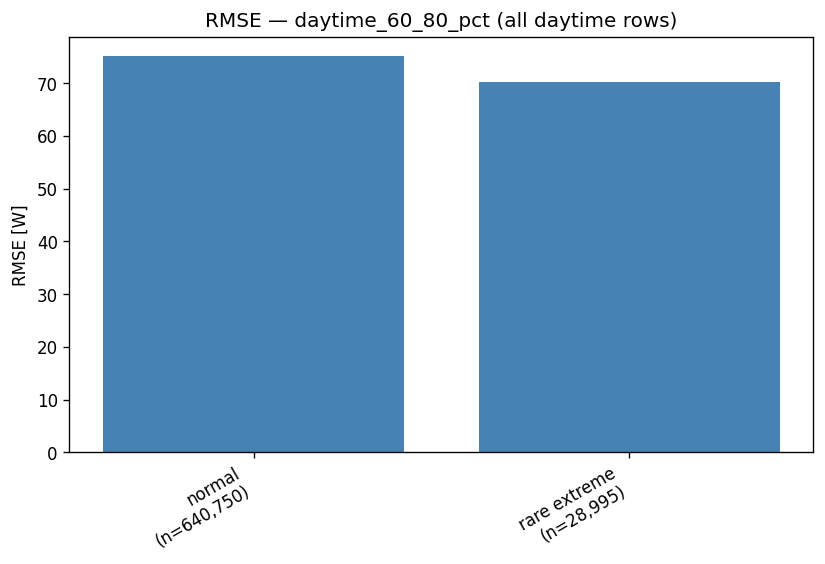

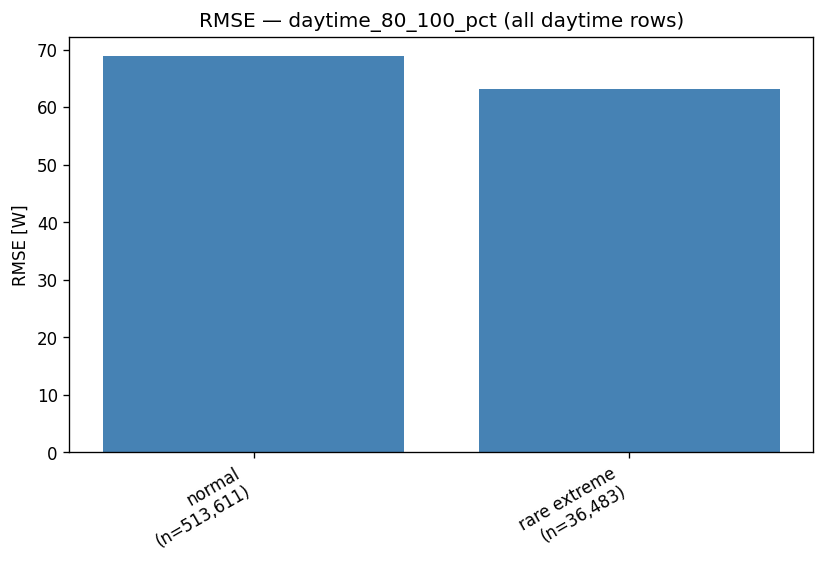

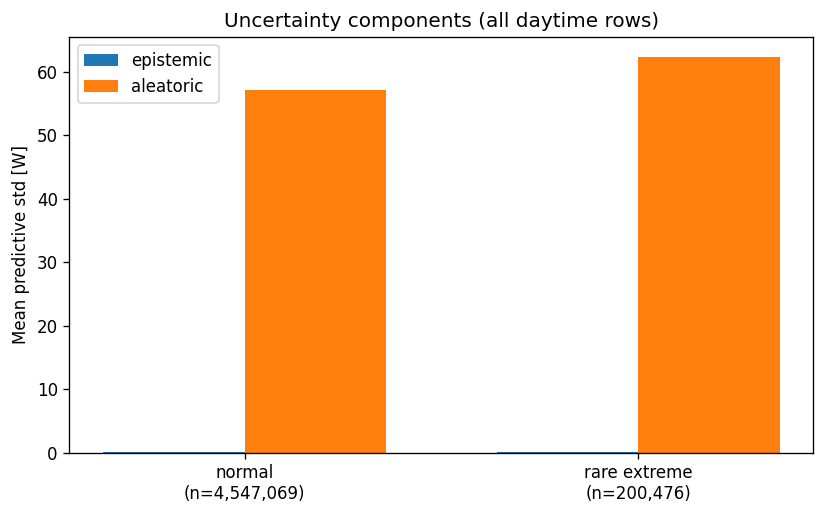

In [40]:
if figure_paths:
    from IPython.display import Image, display
    for path in figure_paths.values():
        display(Image(filename=str(path)))

## Risposta del modello all'evento estremo del 28–29 giugno 2019

La diagnostica usa **tutte le 1.149 località**, senza campionamento. Le aree rosse identificano le ore classificate come evento regionale raro dal protocollo stagionale P97.5.

In [41]:
import importlib
import physiq_pv.reporting.posthoc_outputs as posthoc_outputs
import physiq_pv.experiments.sde_pipeline as pipe

importlib.reload(posthoc_outputs)
pipe = importlib.reload(pipe)

print(pipe.__file__)
print("Funzione disponibile:", hasattr(pipe, "build_extreme_event_diagnostic"))

/home/apedalino/physiq_pv/physiq_pv/experiments/sde_pipeline.py
Funzione disponibile: True


Righe usate (nessun campionamento): 55,152
Soglia regionale stagionale: 0.3532201914708445


,scope,count,locations,timestamps,mae,rmse,picp,mpiw,rare_timestamp_count,mean_y_std,mean_epistemic_std,mean_aleatoric_std
0,all_event_hours,55152,1149,48,20.935136,43.024262,0.977752,140.039325,48,35.724970,0.031935,35.724867
1,daytime,33789,1149,30,34.107910,54.965508,0.963716,226.698796,30,57.832381,0.052082,57.832214
2,regional_rare_hours,55152,1149,48,20.935136,43.024262,0.977752,140.039325,48,35.724970,0.031935,35.724867


,timestamp,n_rows,mean_y_true,mean_y_pred,mean_lower_pi,mean_upper_pi,mae,picp,mpiw,is_rare,mean_y_std,mean_event_score,mean_solar,mean_epistemic_std,mean_aleatoric_std,rmse,regional_anomaly_fraction
0,2019-06-28 00:10:00,1149,0.000000,3.517711e-08,-1.396596,1.396596,3.517711e-08,1.000000,2.793192,True,0.712562,1.680424,0.000000,7.754989e-12,0.712562,3.525089e-08,0.593560
1,2019-06-28 01:10:00,1149,0.000000,4.399956e-08,-1.396596,1.396596,4.399956e-08,1.000000,2.793192,True,0.712562,1.613897,0.000000,1.057934e-11,0.712562,4.410181e-08,0.570061
2,2019-06-28 02:10:00,1149,0.000000,1.254073e-07,-1.396596,1.396596,1.254073e-07,1.000000,2.793192,True,0.712562,1.581865,0.000000,3.638510e-11,0.712562,1.265204e-07,0.558747
3,2019-06-28 03:10:00,1149,0.000000,8.610605e-06,-1.396590,1.396607,8.610605e-06,1.000000,2.793197,True,0.712563,1.525194,0.000000,3.582296e-09,0.712563,9.141005e-06,0.538729
4,2019-06-28 04:10:00,1149,5.222602,3.985760e+00,-0.679117,8.650642,1.348861e+00,0.997389,9.329759,True,2.380084,1.448811,17.052776,2.060196e-03,2.380083,1.699518e+00,0.511749
5,2019-06-28 05:10:00,1149,88.568895,8.735637e+01,37.493951,137.218801,2.275588e+01,0.991297,99.724851,True,25.440479,1.434027,138.796345,2.227977e-02,25.440469,2.553652e+01,0.506527
6,2019-06-28 06:10:00,1149,235.913855,2.385102e+02,158.964307,318.056154,2.276883e+01,0.938207,159.091848,True,40.585398,1.505482,318.024369,4.371815e-02,40.585372,4.359664e+01,0.531767
7,2019-06-28 07:10:00,1149,383.978224,3.799588e+02,287.945305,471.972229,2.092646e+01,0.999130,184.026924,True,46.946501,1.596649,509.548303,6.036899e-02,46.946455,4.708205e+01,0.563969
8,2019-06-28 08:10:00,1149,508.987267,5.119527e+02,443.806449,580.099007,1.720545e+01,0.996519,136.292558,True,34.769147,1.697672,685.027850,4.033656e-02,34.769117,3.574142e+01,0.599652
9,2019-06-28 09:10:00,1149,605.419644,6.068188e+02,542.580892,671.056620,1.500277e+01,0.994778,128.475727,True,32.775019,1.806086,823.543081,5.889517e-02,32.774959,2.407578e+01,0.637946


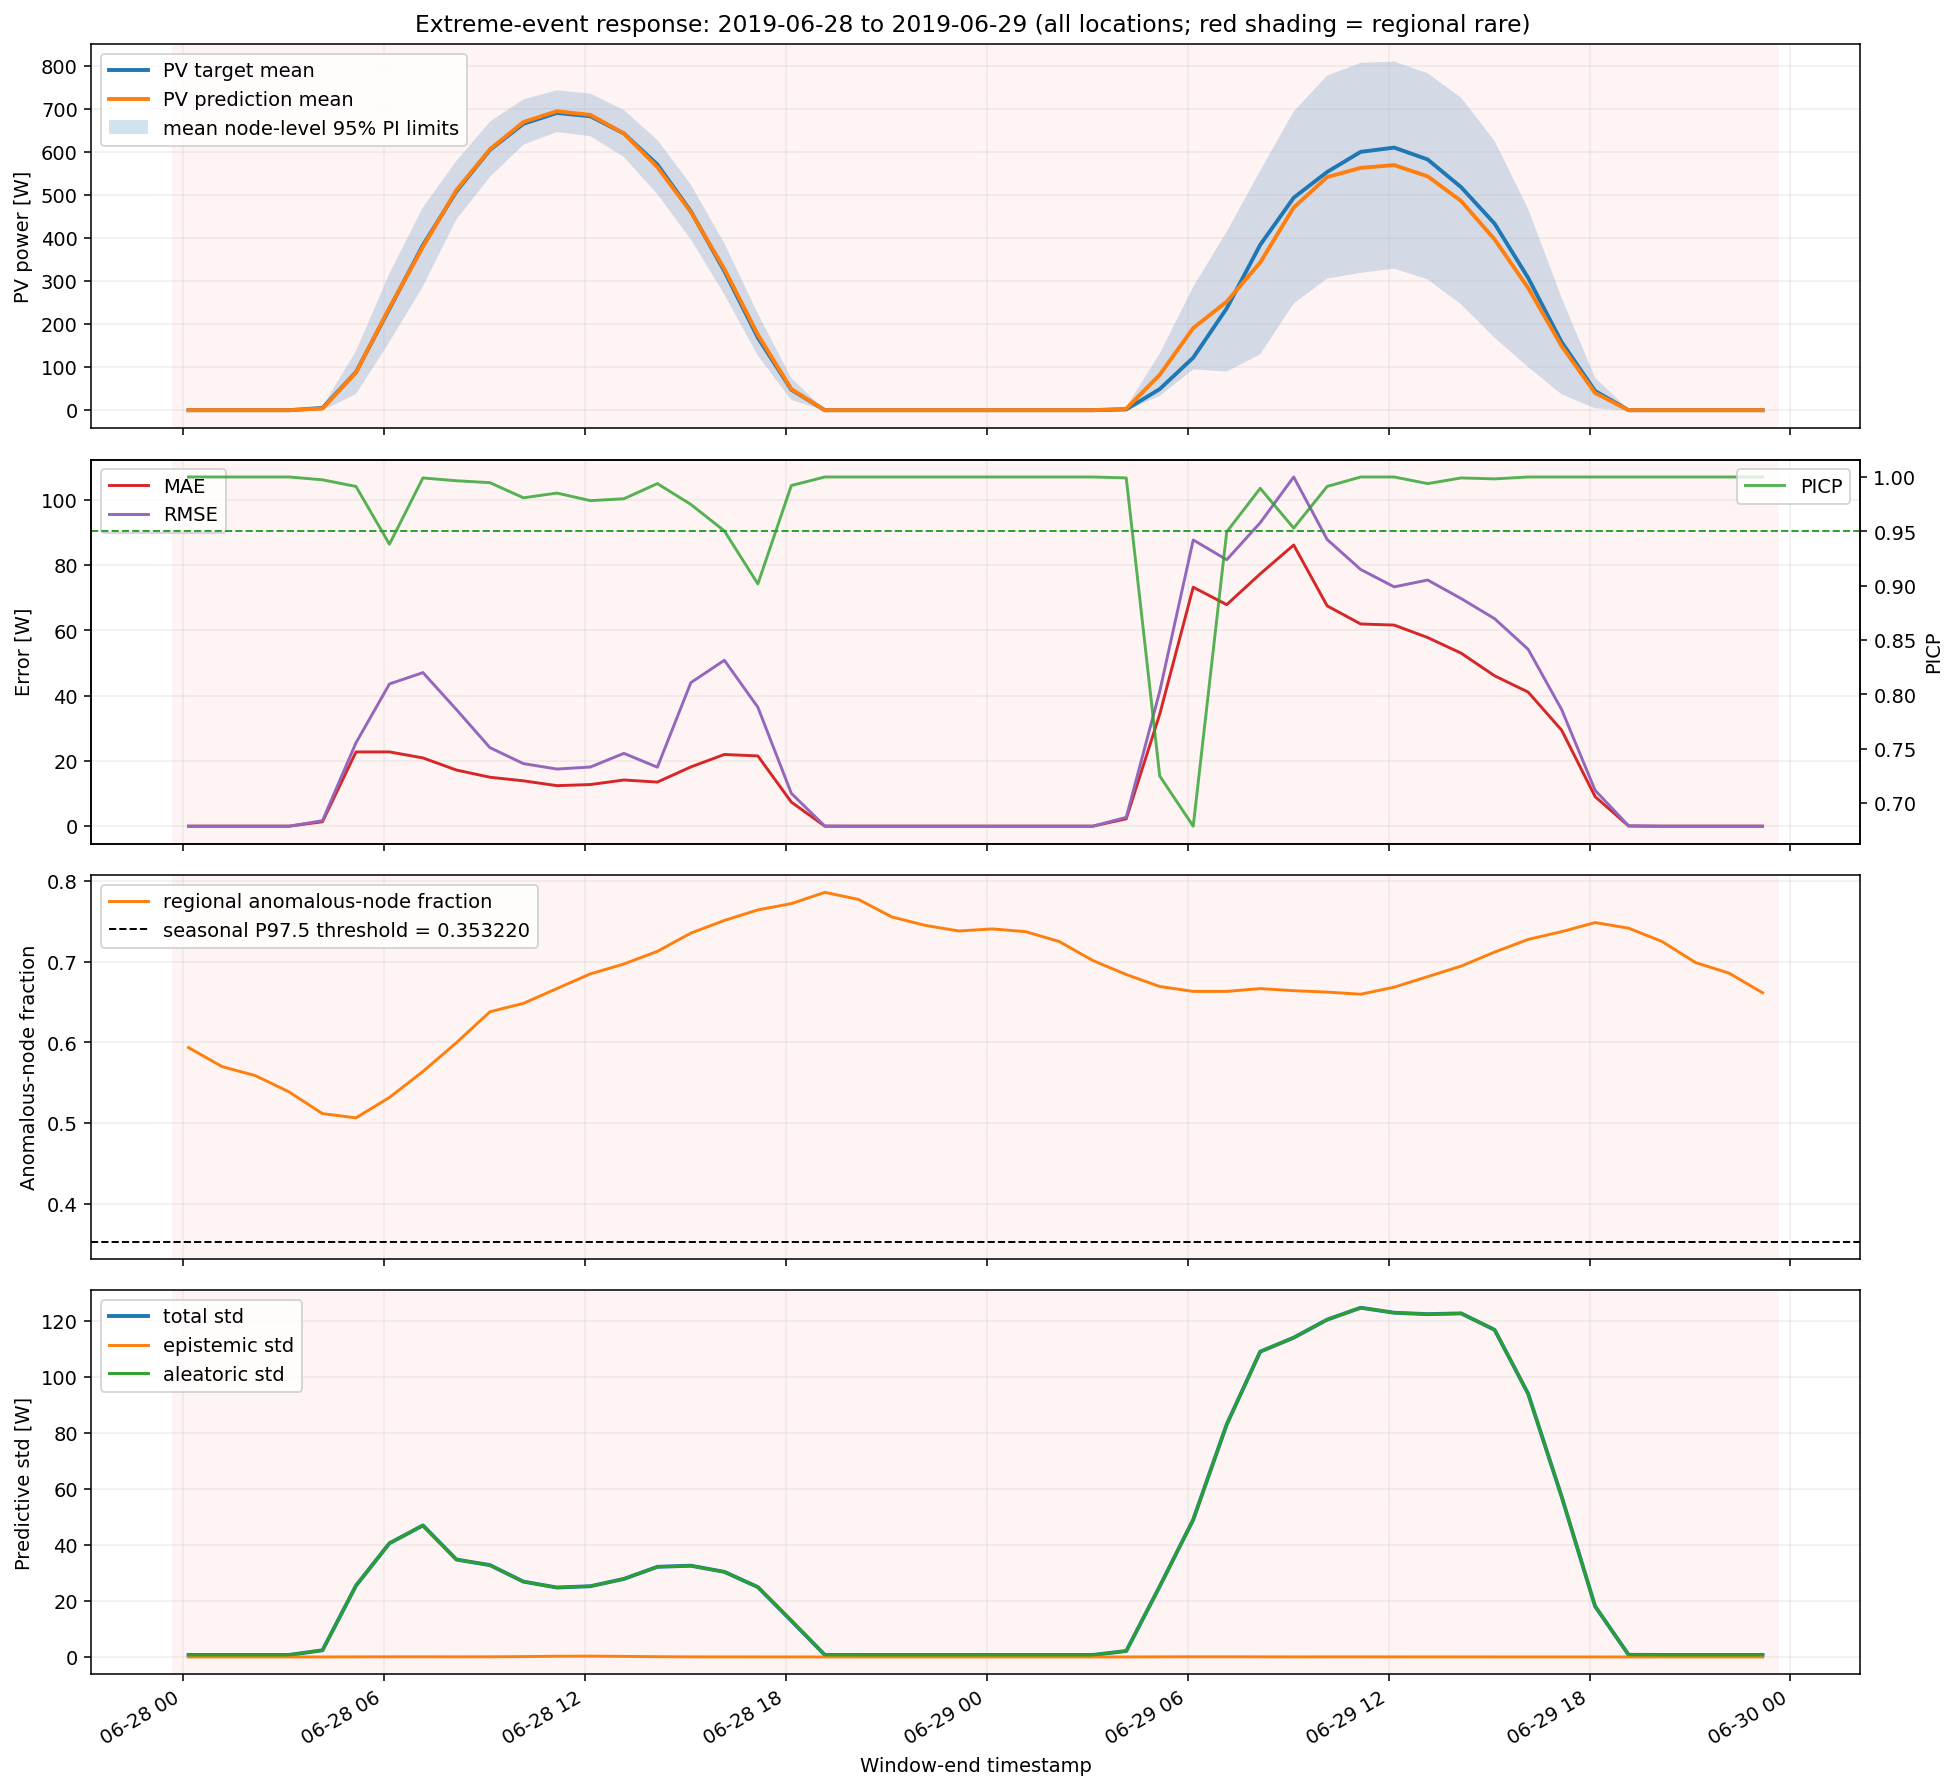

CSV orario: outputs/pvgis_stgnn_paper_faithful_gaussian_detector_mtgflow_ep60_seed1/extreme_event_20190628_20190629_hourly.csv
CSV riepilogo: outputs/pvgis_stgnn_paper_faithful_gaussian_detector_mtgflow_ep60_seed1/extreme_event_20190628_20190629_summary.csv


In [42]:
import importlib
from IPython.display import Image, display

pipe = importlib.reload(pipe)
extreme_event = pipe.build_extreme_event_diagnostic(
    out_dir,
    start='2019-06-28',
    end='2019-06-30',  # estremo escluso: include tutto il 28 e 29 giugno
)
print(f"Righe usate (nessun campionamento): {extreme_event['rows_used']:,}")
print('Soglia regionale stagionale:', extreme_event['regional_threshold'])
display(extreme_event['summary'])
display(extreme_event['hourly'])
display(Image(filename=str(extreme_event['figure_path'])))
print('CSV orario:', extreme_event['hourly_path'])
print('CSV riepilogo:', extreme_event['summary_path'])

## Confronto: normale 2019 vs 28 giugno vs 29 giugno

Boxplot, istogrammi e metriche usano **tutte le predizioni diurne valide**, senza campionamento, e sono separati nelle fasce 0–20%, 20–40%, 40–60%, 60–80% e 80–100% della potenza di riferimento.

,bin,category,count,mae,rmse,mpiw,nmpil,picp,clc
0,daytime_0_20_pct,normal_2019,1853036,39.404498,67.117756,166.551778,0.186747,0.941304,0.388696
1,daytime_0_20_pct,2019-06-28,3870,23.881705,52.356328,76.300575,0.085552,0.930491,0.187525
2,daytime_0_20_pct,2019-06-29,4104,45.137272,70.884725,137.854655,0.154570,0.824318,0.633611
3,daytime_20_40_pct,normal_2019,826945,46.193109,68.895114,254.599529,0.285470,0.947061,0.578593
4,daytime_20_40_pct,2019-06-28,1966,11.312399,18.334750,118.850530,0.133261,0.995931,0.221402
5,daytime_20_40_pct,2019-06-29,2379,50.007814,73.439215,313.294284,0.351282,0.970156,0.644287
6,daytime_40_60_pct,normal_2019,712727,46.445237,69.593098,278.889988,0.312706,0.960443,0.597359
7,daytime_40_60_pct,2019-06-28,2200,13.136344,22.609148,139.007531,0.155862,0.995909,0.258972
8,daytime_40_60_pct,2019-06-29,2783,54.421662,70.678385,451.639297,0.506402,0.988502,0.864503
9,daytime_60_80_pct,normal_2019,640750,45.250091,75.061982,273.228459,0.306358,0.967204,0.568771


CSV metriche: outputs/pvgis_stgnn_paper_faithful_gaussian_detector_mtgflow_ep60_seed1/extreme_event_comparison_metrics.csv
Grafici creati: 20


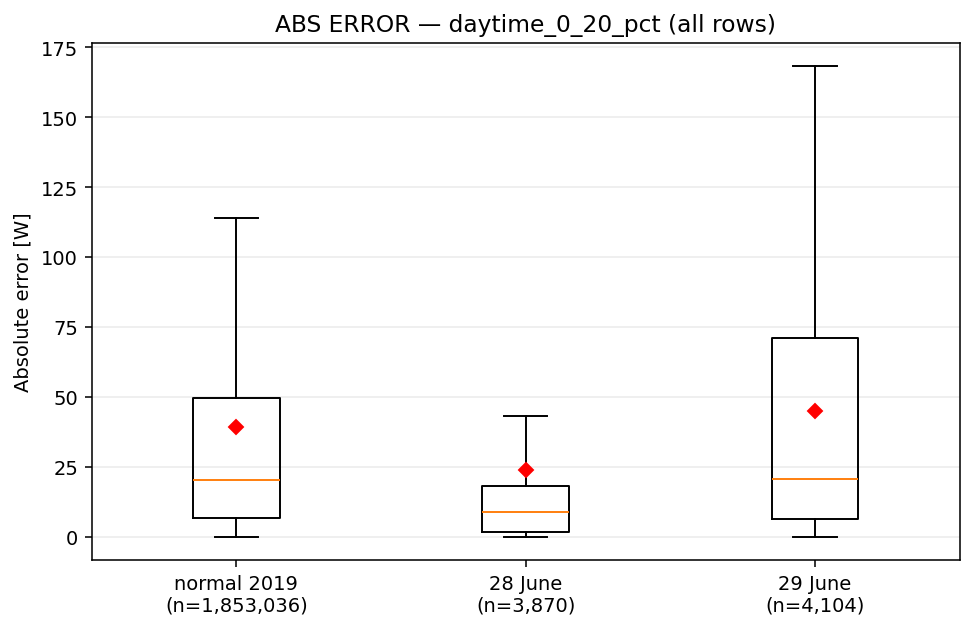

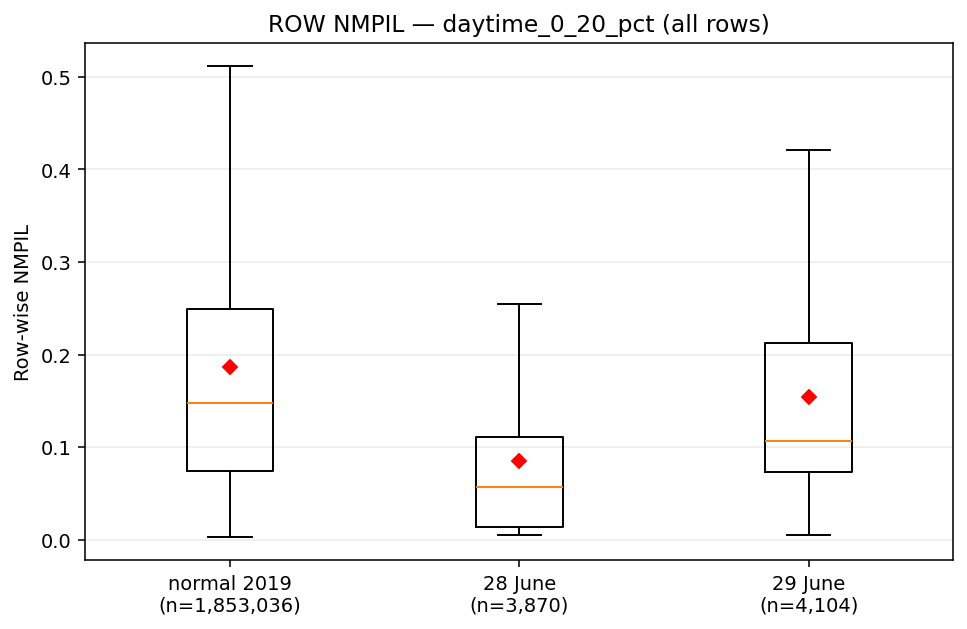

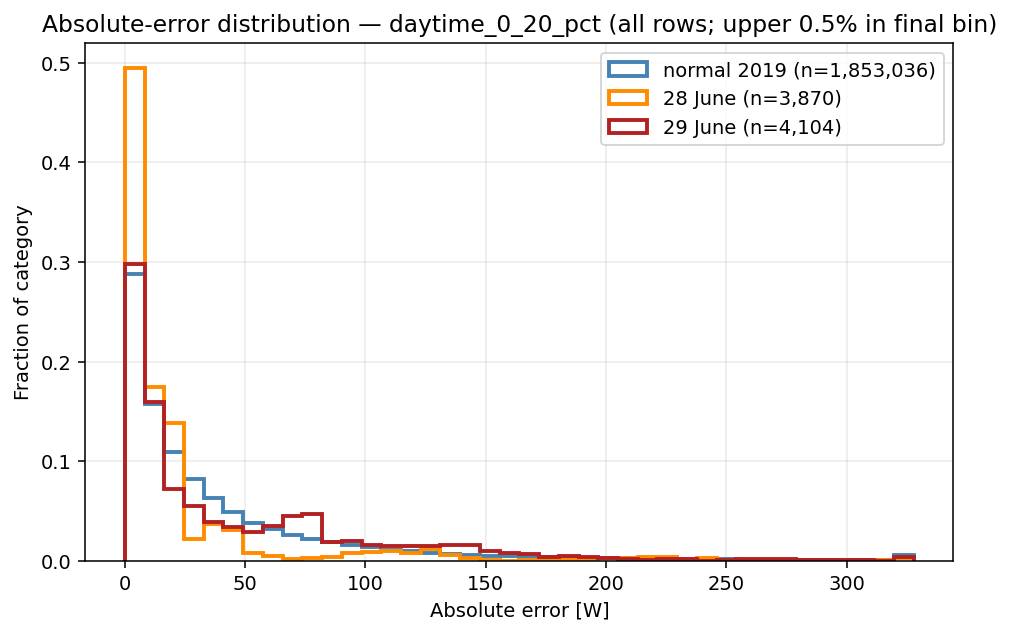

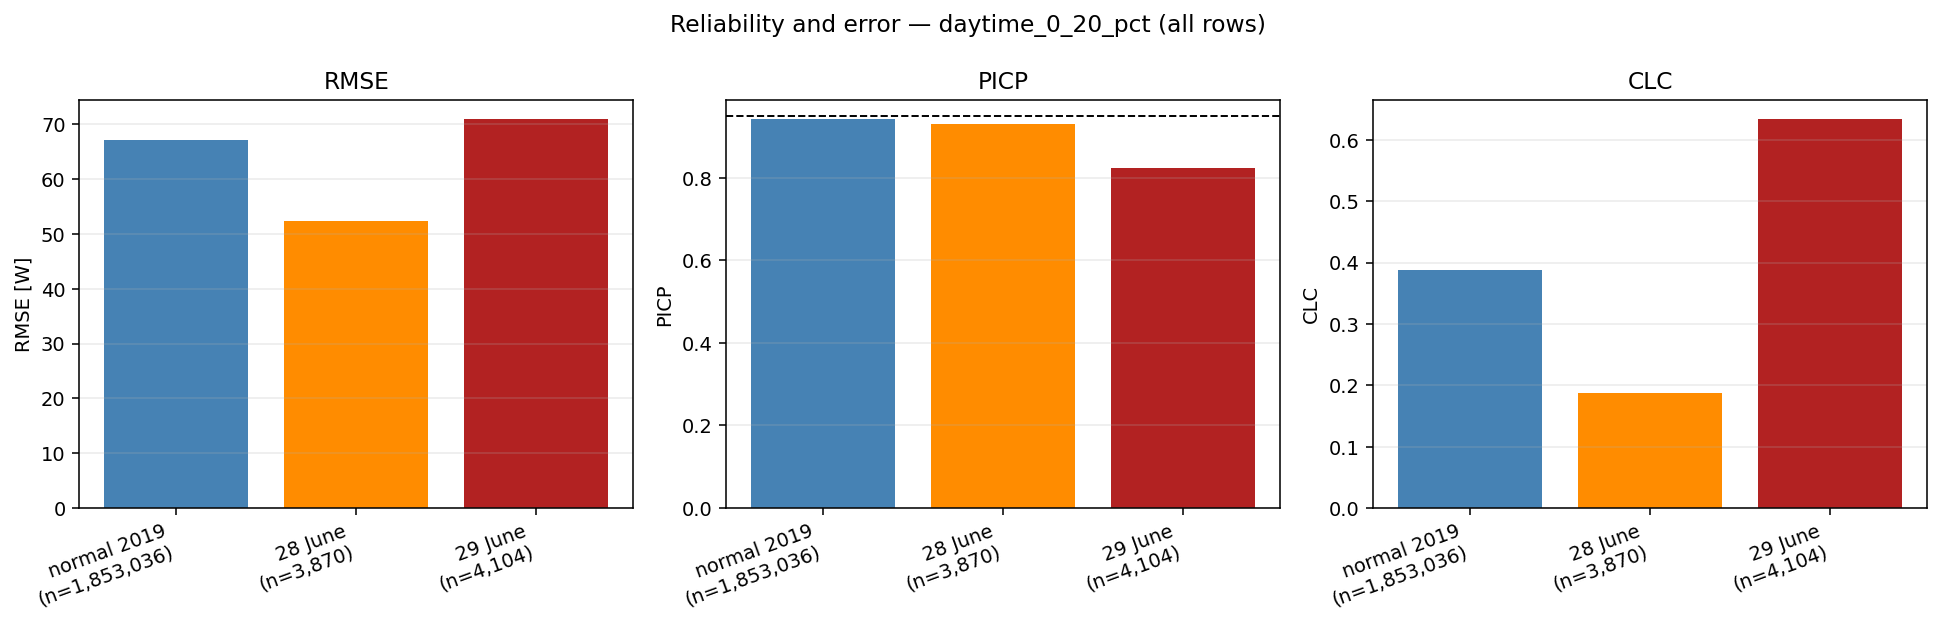

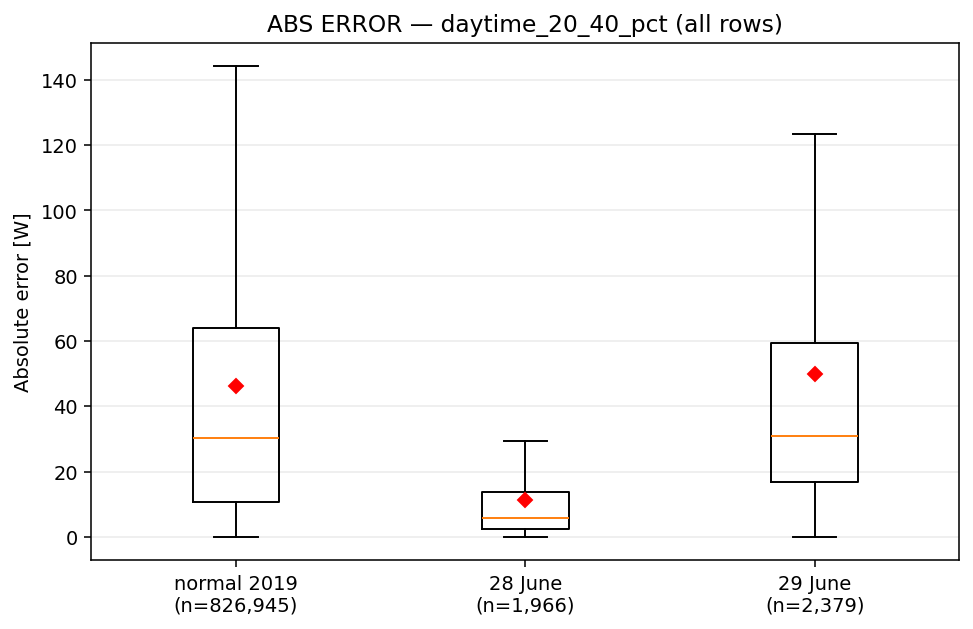

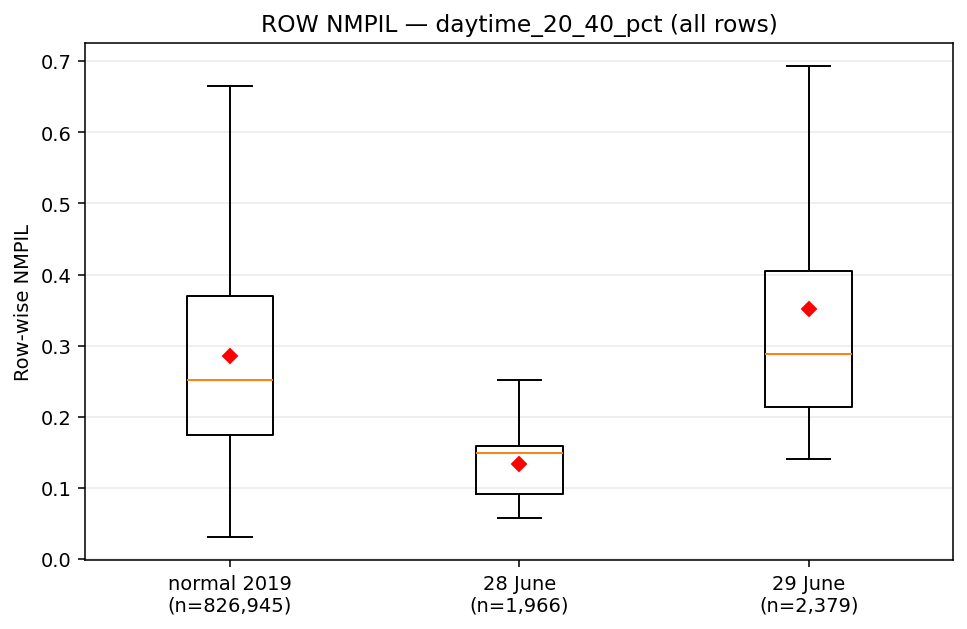

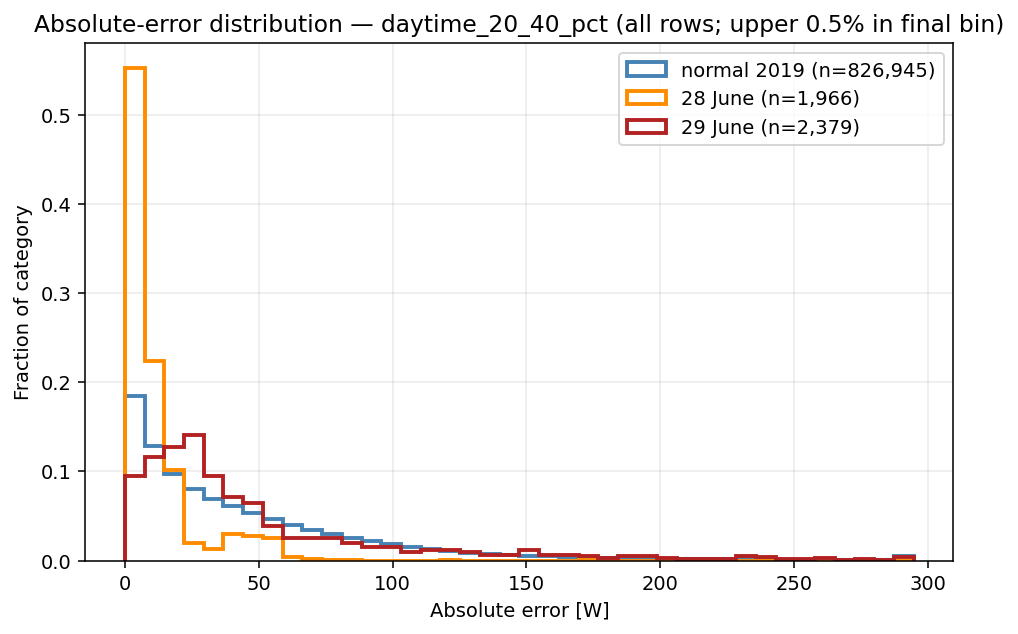

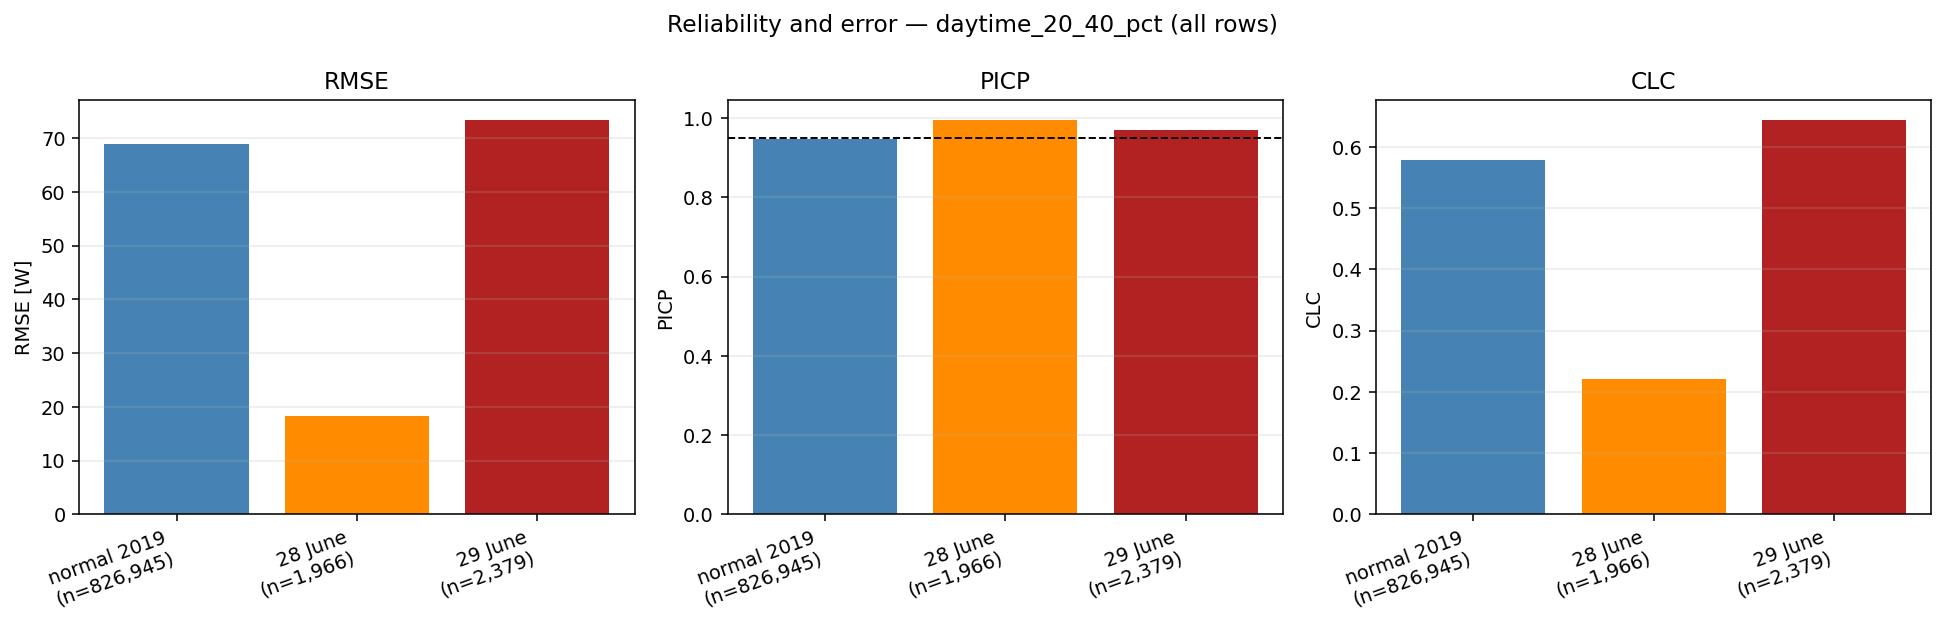

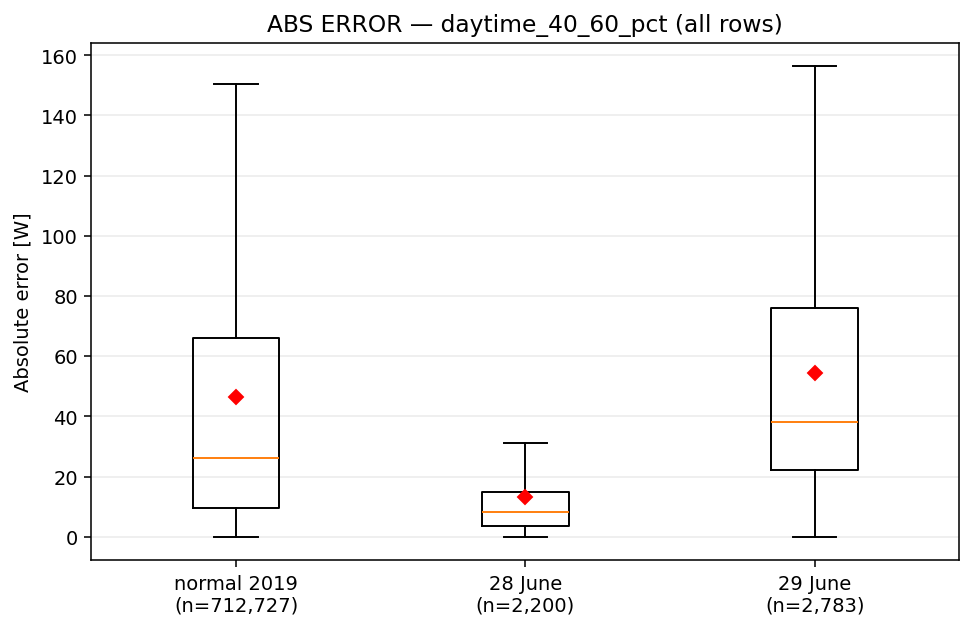

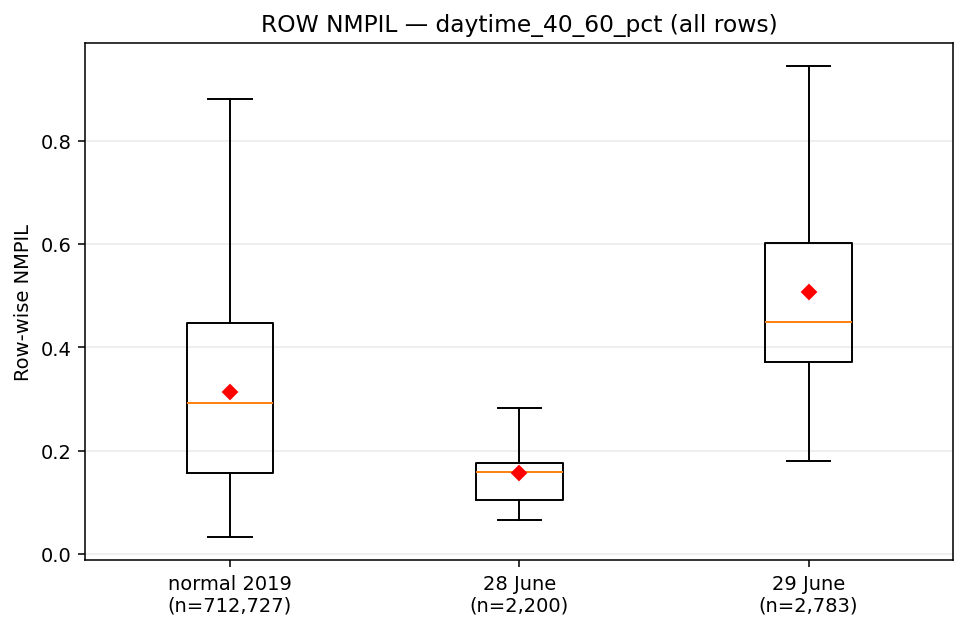

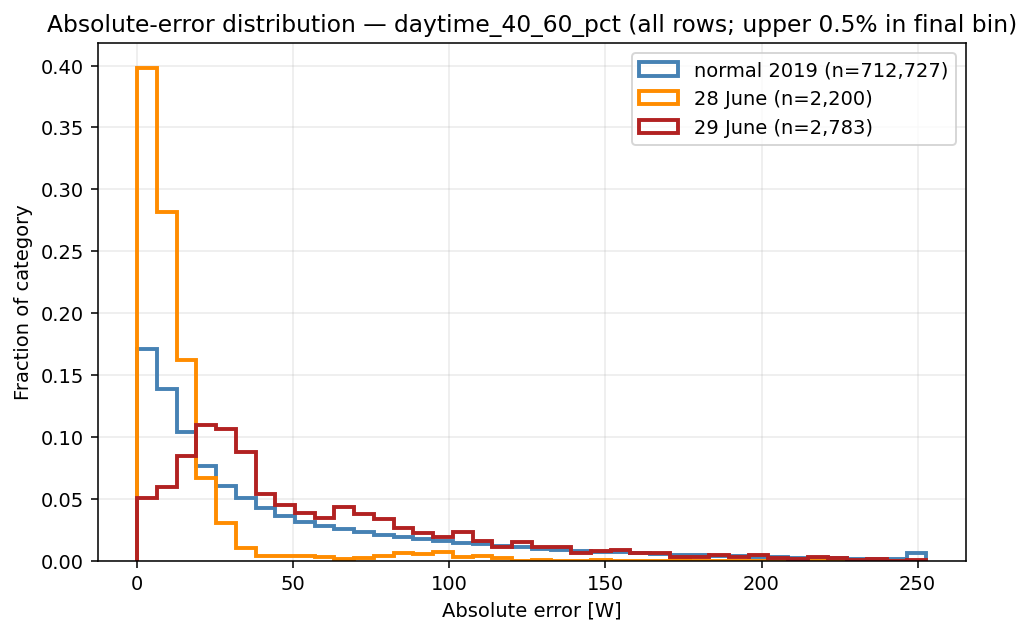

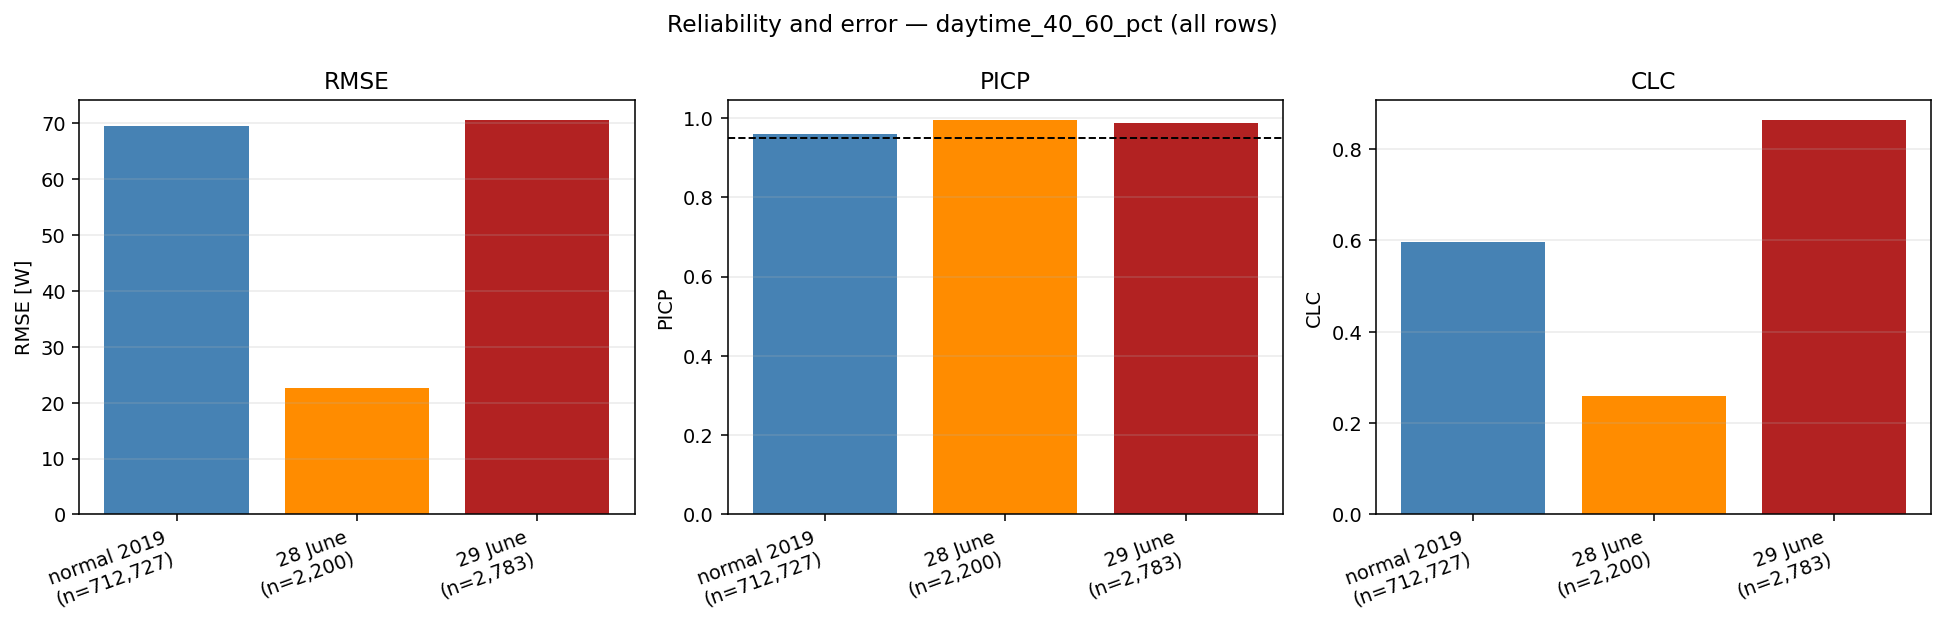

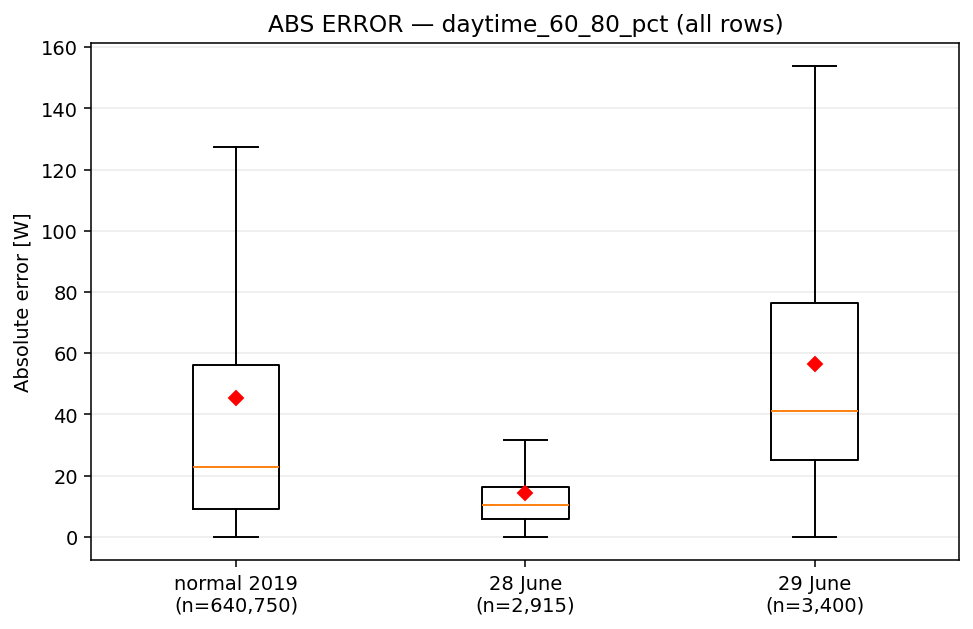

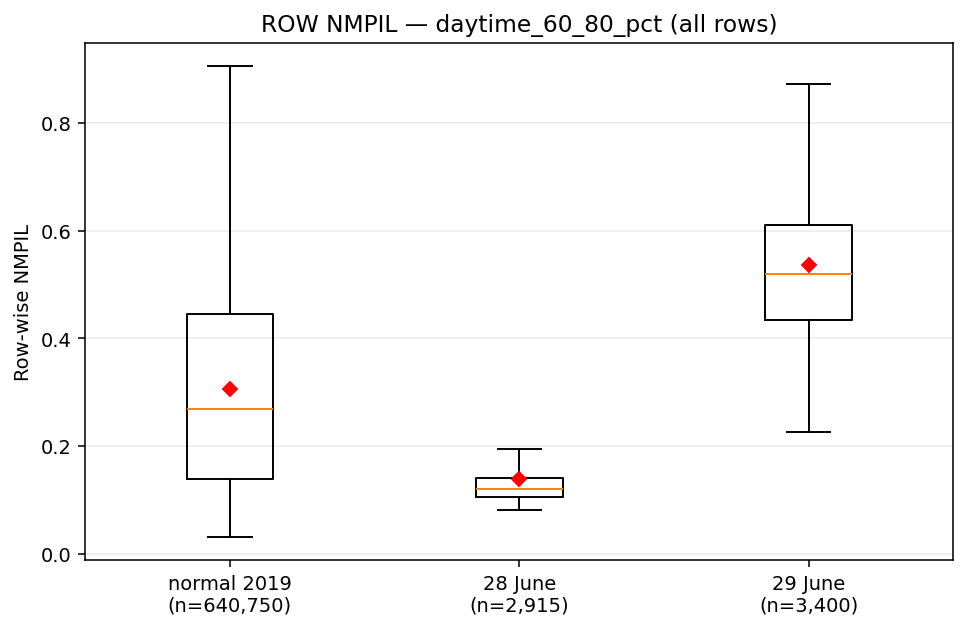

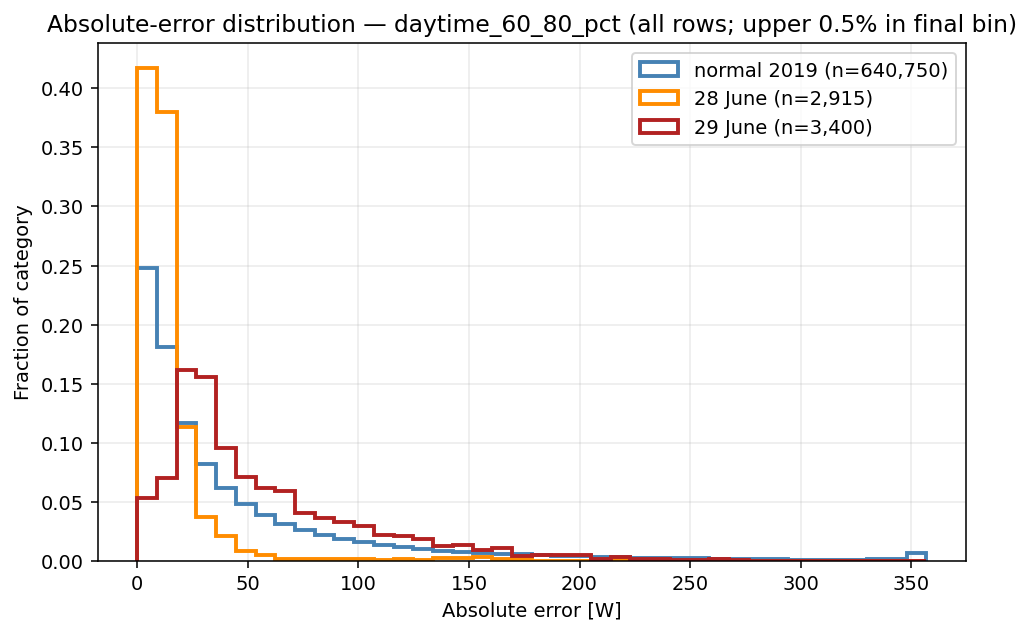

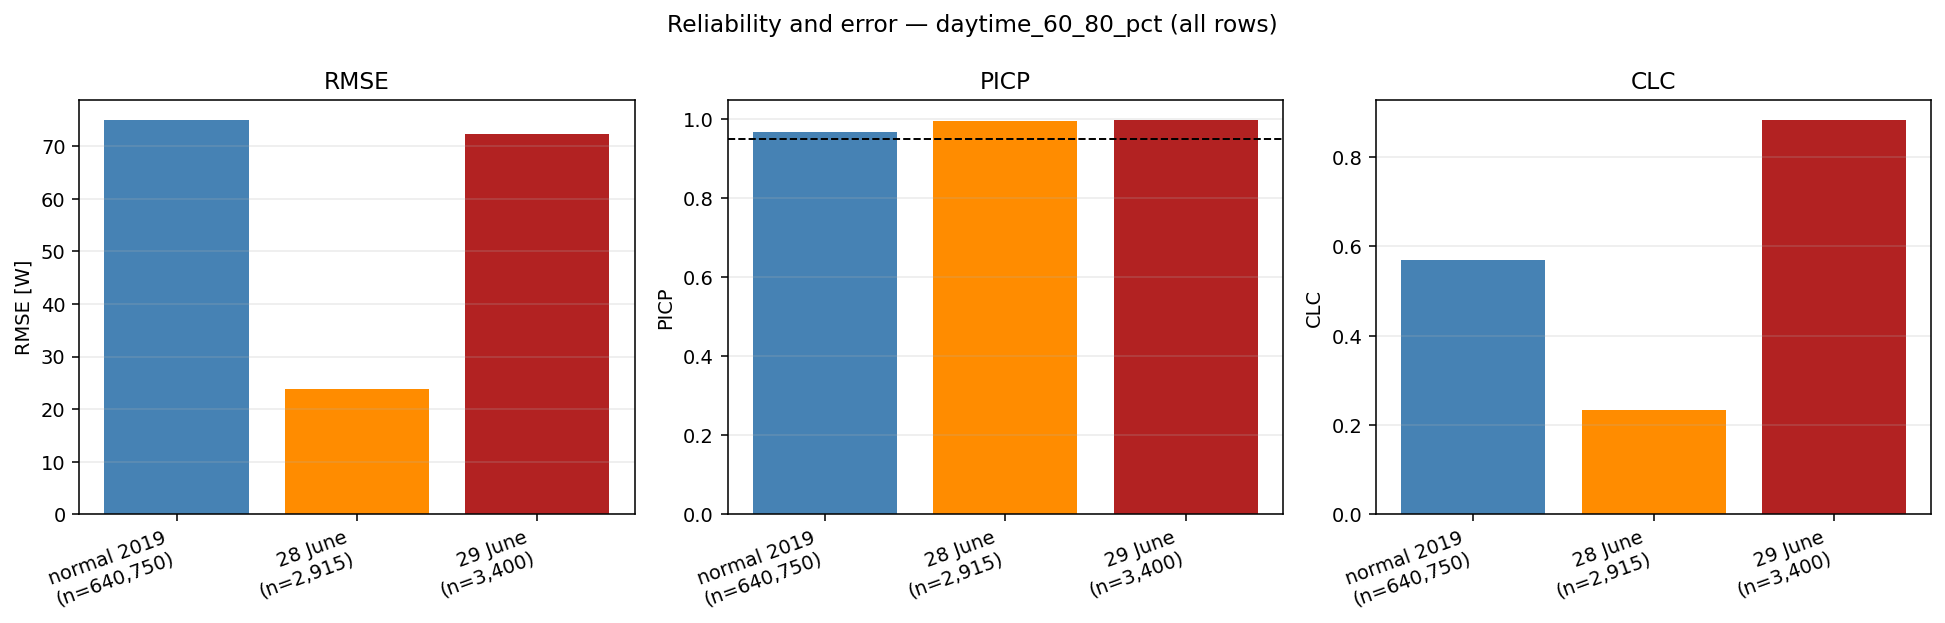

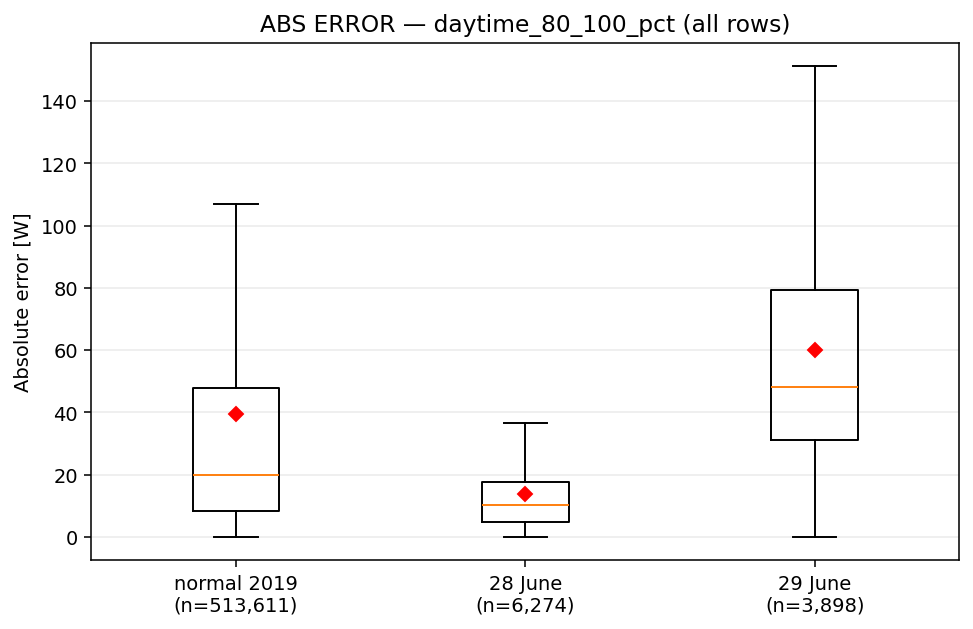

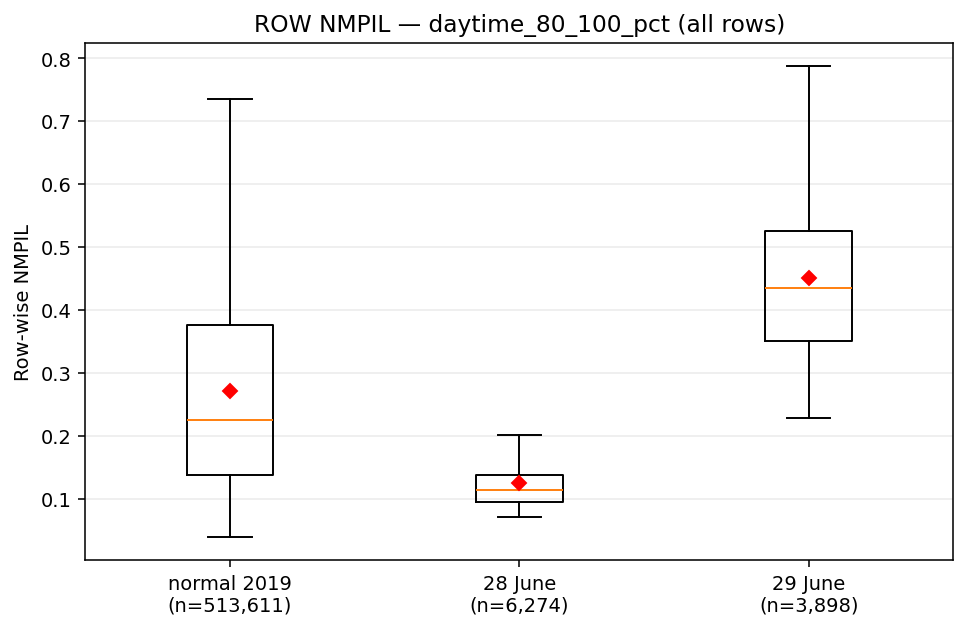

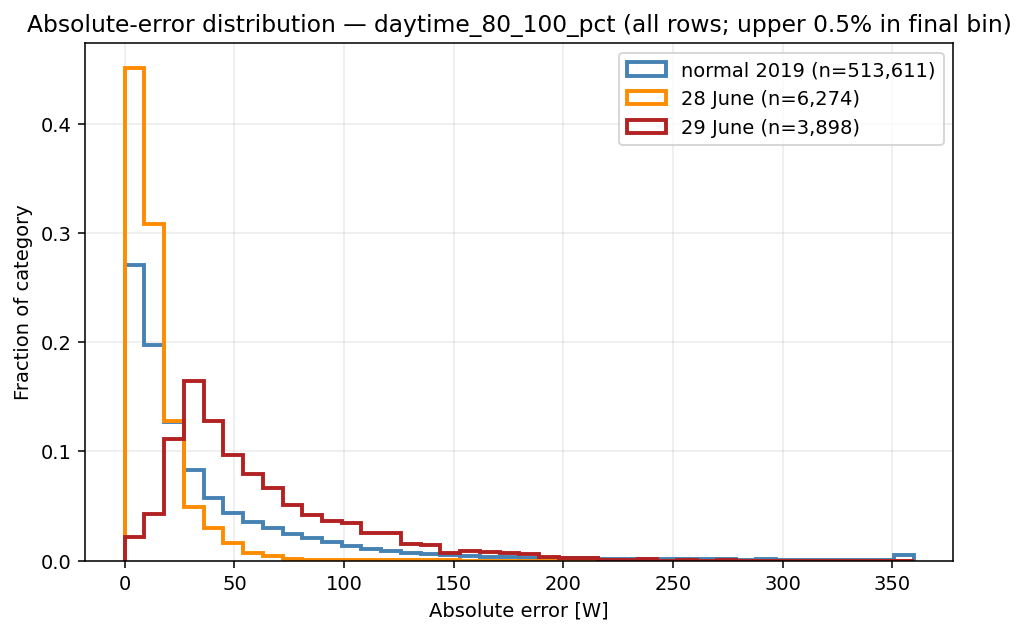

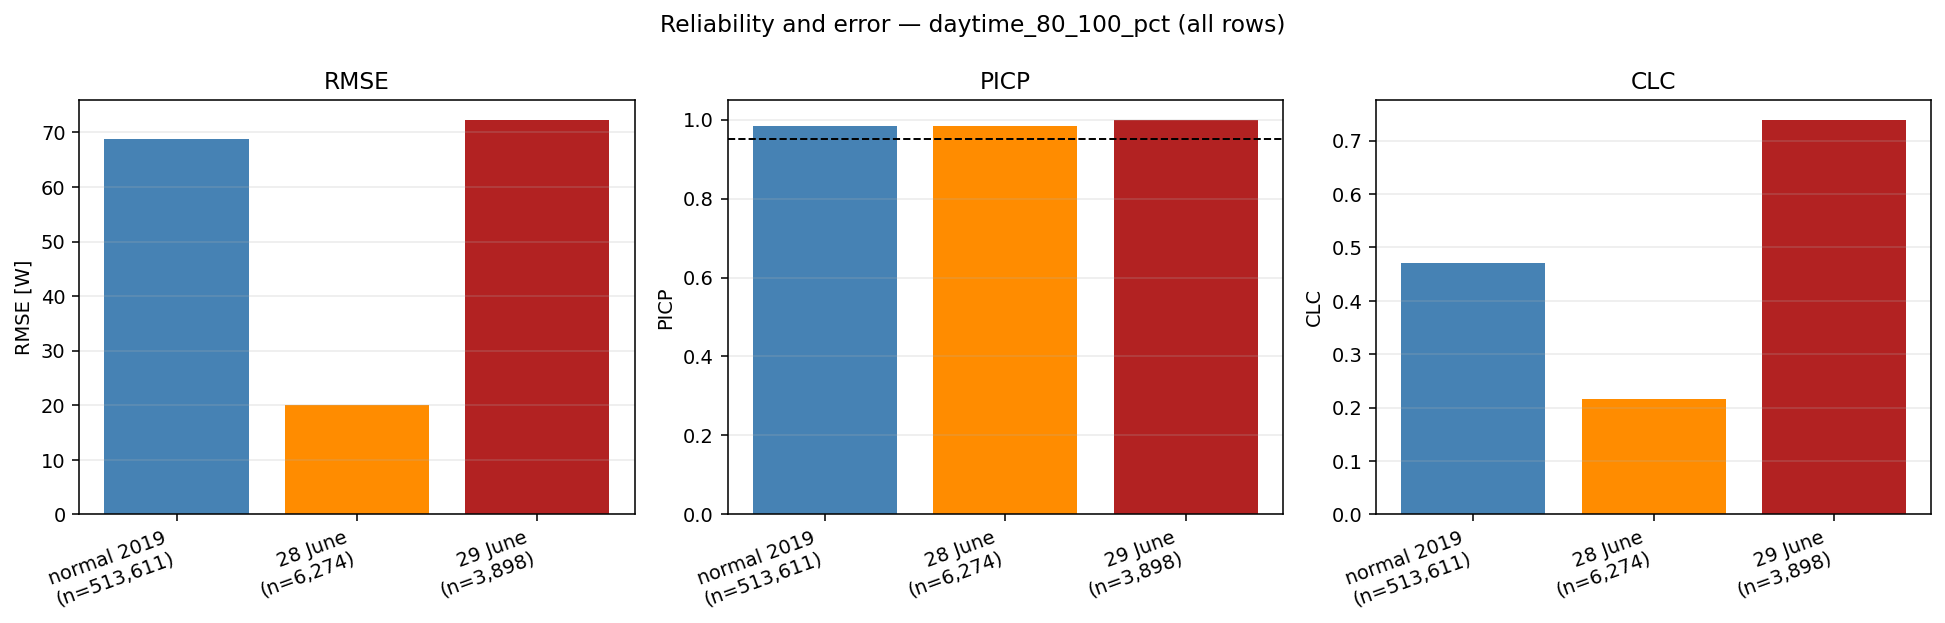

In [43]:
pipe = importlib.reload(pipe)
event_comparison = pipe.build_extreme_event_comparison_figures(
    out_dir,
    event_dates=('2019-06-28', '2019-06-29'),
)
display(event_comparison['metrics'])
print('CSV metriche:', event_comparison['metrics_path'])
print('Grafici creati:', len(event_comparison['figure_paths']))
for figure_path in event_comparison['figure_paths'].values():
    display(Image(filename=str(figure_path)))

## 7. W&B sweep (optional)

In [ ]:
print('Sweep disabled: this notebook defines one controlled exploratory run.')

In [ ]:
# Intentionally no W&B sweep registration in the single-run notebook.

## 8. Log post-hoc results to W&B (optional)

Adds post-hoc scalars and figures to the matching W&B run without uploading artifacts.
The sweep wrapper does this automatically per run.

In [ ]:
LOG_TO_WANDB = True
if LOG_TO_WANDB:
    import wandb
    run = pipe.init_wandb_run_for_out_dir(wandb, out_dir, run_name=run_name)
    try:
        posthoc = pipe.log_posthoc_to_wandb(
            wandb, run, out_dir,
            figure_paths=figure_paths if 'figure_paths' in dir() else None,
            upload_artifact=False,
        )
        print(posthoc['summary'])
        print('posthoc artifact upload disabled; uploaded:', posthoc['artifact_uploaded'])
    finally:
        run.finish()
else:
    print('LOG_TO_WANDB is False. posthoc summary preview:')
    if Path(out_dir, 'sharpness_overview.csv').exists():
        print(pipe.read_posthoc_summary(out_dir))